<div class="alert alert-block alert-info">
  <center> <h1> Exploratory Data Analysis 
  - Amazing International Airlines Inc. </h1> </center> <br>
  <center> <h2> Group 92 </h2> </center> <br>
  <center <h3> notebook  </h3> </center>
  <center> <h3> 2025/2026 </h3> </center>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra salih
student id      -   123567
contact email   -   esra.salih@example.com

# Table of Content



**0. [Context and Metadata](#0-context)**  

**1. [Importing Libraries and Loading Data](#importing-libraries-and-data)**  
   - [1.1 Importing Libraries](#importing-libraries)  
   - [1.2 Loading and Reading Data](#loading-and-reading-data)  
   - [1.3 Brief Preliminary Analysis](#brief-preliminary-analysis)
- **2. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)** 

   - **2.1. [Validity check of the column values](#validity-check)**  
      - [2.1.1. Checking for Missing Values](#missing-values)  
      - [2.1.2. Checking for Duplicates](#duplicates)  
      - [2.1.3. Checking for Outliers](#outliers)
  




# 0. Context and Metadata <a class="anchor" id="0-context"></a>

Text text text

Metadata

CustomerDB 


FlightsDB

Examples:

`customer_id` - Unique identifier for each customer <br>
`customer_region` - Geographic region where the customer is located <br>
`customer_age` - Age of the customer <br>
`vendor_count` - Number of unique vendors the customer has ordered from <br>
`product_count` - Total number of products the customer has ordered <br>
`is_chain` - Indicates whether the customer’s order was from a chain restaurant <br>
`first_order` - Number of days from the start of the dataset when the customer first placed an order. <br>
`last_order` - Number of days from the start of the dataset when the customer most recently placed an order. <br>
`last_promo` - The category of the promotion or discount most recently used by the customer. <br>
`payment_method` - Method most recently used by the customer to pay for their orders. <br>
`CUI_(cuisine)`- The amount in monetary units spent by the customer from the indicated type of cuisine. <br>
- CUI_Beverages, CUI_Cafe', 'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts','CUI_Healthy', 'CUI_Indian', 'CUI_Italian', 'CUI_Japanese', 'CUI_Noodle Dishes', 'CUI_OTHER', 'CUI_Street Food / Snacks', CUI_Thai <br>

`DOW_0 to DOW_6` - Number of orders placed on each day of the week (0 = Sunday, 6 = Saturday). <br>
`HR_0 to HR_23` - Number of orders placed during each hour of the day (0 = midnight, 23 = 11 PM). <br>
ders.

## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [474]:
# pip install pandas 
# pip install numpy 
# pip install matplotlib 
# pip install seaborn 
# pip install plotly 
# pip install pyyaml
# pip install geopandas

In [475]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import plotly.express as px
from matplotlib.lines import Line2D
import math
import geopandas as gpd

## 1.2. Loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>

In [476]:
# directory with raw CSV files
data_dir = Path("../data/raw")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_CustomerDB.csv', 'DM_AIAI_FlightsDB.csv', 'DM_AIAI_Metadata.csv']


In [477]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16921, 21)
Flights shape: (608436, 10)


In [478]:
customers_original = customers.copy()
flights_original = flights.copy()

## 1.3. Brief Preliminary Analysis <a class="anchor" id="brief-preliminary-analysis"></a>

In [479]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [480]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [481]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,8440.023639,4884.775439,0.000000,4210.000000,8440.000000,12670.000000,16900.000000
Loyalty#,16921.0,550197.393771,259251.503597,100011.000000,326823.000000,550896.000000,772438.000000,999999.000000
Latitude,16921.0,47.174500,3.307971,42.984924,44.231171,46.087818,49.282730,60.721188
Longitude,16921.0,-91.814768,22.242429,-135.056840,-120.237660,-79.383186,-74.596184,-52.712578
Income,16901.0,37758.038400,30368.992499,0.000000,0.000000,34161.000000,62396.000000,99981.000000
Customer Lifetime Value,16901.0,7990.460188,6863.173093,1898.010000,3979.720000,5780.180000,8945.690000,83325.380000


In [482]:
customers.describe(include='object').T

,count,unique,top,freq
First Name,16921,4941,Stacey,13
Last Name,16921,15404,Ypina,4
Customer Name,16921,16921,Emma Martin,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [483]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [484]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [485]:
flights.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,550037.873084,258935.180575,100018.0,326961.00,550834.000,772194.0000,999986.0
Year,608436.0,2020.000000,0.816497,2019.0,2019.00,2020.000,2021.0000,2021.0
Month,608436.0,6.500000,3.452055,1.0,3.75,6.500,9.2500,12.0
NumFlights,608436.0,3.908107,5.057889,0.0,0.00,0.000,7.2000,21.0
NumFlightsWithCompanions,608436.0,0.983944,2.003785,0.0,0.00,0.000,0.9000,11.0
DistanceKM,608436.0,7939.341419,10260.421873,0.0,0.00,856.400,15338.1750,42040.0
PointsAccumulated,608436.0,793.777781,1025.918521,0.0,0.00,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,235.251678,983.233374,0.0,0.00,0.000,0.0000,7496.0
DollarCostPointsRedeemed,608436.0,2.324835,9.725168,0.0,0.00,0.000,0.0000,74.0


In [486]:
flights.describe(include='object').T

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


Remove the column "Unnamed: 0" because it is not needed and has no context in the data.

In [487]:
if "Unnamed: 0" in customers.columns:
	customers.drop(columns=["Unnamed: 0"], inplace=True)

In [488]:
if "Unnamed: 0" in customers.columns:
	customers.drop(columns=["Unnamed: 0"], inplace=True)

# 2. Missing Values and Data Validity Check  <a class="anchor" id="Data_Validity_Check"></a>


Some text to describe what we are doing here.

In [489]:
# Converting the datatype of categorical features from object to category
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], format='%m/%d/%Y')

# Convert NumFlights and NumFlightsWithCompanions to integer type (they are float by default)
flights["NumFlights"] = flights["NumFlights"].astype(int)
flights["NumFlightsWithCompanions"] = flights["NumFlightsWithCompanions"].astype(int)

In [490]:
# Check the datatype of YearMonthDate column
flights['YearMonthDate'].dtype

dtype('<M8[ns]')

## 2.1. Missing Values <a class="anchor" id="missing-values"></a>

Some text to describe what we are doing here.

In [491]:
# Check for missing values
print("Missing values in CustomerDB:")
display(customers.isna().sum())

print("\nMissing values in FlightsDB:")
display(flights.isna().sum())


Missing values in CustomerDB:


Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64


Missing values in FlightsDB:


Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [492]:
missing_ratio = customers.isna().mean().sort_values(ascending=False)
print((missing_ratio * 100).round(2))

CancellationDate           86.35
Income                      0.12
Customer Lifetime Value     0.12
Loyalty#                    0.00
Customer Name               0.00
Last Name                   0.00
First Name                  0.00
Country                     0.00
Longitude                   0.00
Province or State           0.00
City                        0.00
Latitude                    0.00
Education                   0.00
Gender                      0.00
Postal code                 0.00
Location Code               0.00
LoyaltyStatus               0.00
Marital Status              0.00
EnrollmentDateOpening       0.00
EnrollmentType              0.00
dtype: float64


The flights dataset is clean. The customers dataset has missing values in the columns "CancellationDate", "Customer Lifetime Value" and "Income". We start with analyzing the CancellationDate column. We expect that, these missing values correspond to customers who have not cancelled their subscription. We will check this assumption by looking at some entries with missing CancellationDate values.

In [493]:
# select first 10 rows where CancellationDate is NaN
active_customers = customers[customers["CancellationDate"].isna()].head(10)
active_customers

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
5,193662,Leatrice,Hanlin,Leatrice Hanlin,Canada,Yukon,Whitehorse,60.721188,-135.056840,Y2K 6R0,male,Bachelor,Rural,26262.0,Married,Star,5/7/2015,NaN,3844.57,Standard
6,927943,Hue,Sellner,Hue Sellner,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,female,College,Urban,0.0,Single,Star,6/9/2017,NaN,3857.95,Standard
7,188893,Nakia,Cash,Nakia Cash,Canada,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,Bachelor,Suburban,93272.0,Married,Star,12/8/2019,NaN,3861.49,Standard
8,852392,Arlene,Conterras,Arlene Conterras,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Suburban,93272.0,Married,Star,5/30/2018,NaN,3861.49,Standard
9,866307,Dustin,Recine,Dustin Recine,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Suburban,93272.0,Married,Star,10/14/2019,NaN,3861.49,Standard
10,932823,Jeremy,Dickason,Jeremy Dickason,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,female,Bachelor,Suburban,47199.0,Married,Star,3/17/2018,NaN,3863.31,Standard


The Entries seem to look fine. The expectation seems to be correct. We will add a new column in the Data Engineering section to indicate whether a customer is active or not based on the CancellationDate column.

Next we check the missing values in the "Customer Lifetime Value" and "Income" columns. 

In [494]:
# rows where Income is missing
missing_income = customers[customers["Income"].isna()]
print("Rows with missing Income:", missing_income.shape[0])
display(missing_income.head(5))

Rows with missing Income: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [495]:
# rows where Customer Lifetime Value is missing
missing_clv = customers[customers["Customer Lifetime Value"].isna()]
print("Rows with missing Customer Lifetime Value:", missing_clv.shape[0])
display(missing_clv.head(5))

Rows with missing Customer Lifetime Value: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [496]:
# Check if the missing values in Income and Customer Lifetime Value overlap
missing_income_indices = set(missing_income.index)
missing_clv_indices = set(missing_clv.index)
overlapping_indices = missing_income_indices.intersection(missing_clv_indices)

print("Rows with missing values in both Income and Customer Lifetime Value:", len(overlapping_indices))

Rows with missing values in both Income and Customer Lifetime Value: 20


The missing values in Income and Customer Lifetime Value do overlap fully. This means that all rows with missing Income also have missing Customer Lifetime Value. This could indicate a correlation between the two columns, or it could be due to data collection issues. Only 20 rows are affected, which is a small fraction of the total dataset. Deleting these rows might be a reasonable approach for the second part of the project. But for now we will keep them as is.

## 2.2. Validity check <a class="anchor" id="validity-check"></a>

We check all the columns for validity of the values. 

### 2.2.1 Categorical Features of customers <a class="anchor" id="categorical-features"></a>

In [497]:
# List all categorical columns in customers
cat_columns_customers = customers.select_dtypes(include=['object']).columns.tolist()
cat_columns_customers

['First Name',
 'Last Name',
 'Customer Name',
 'Country',
 'Province or State',
 'City',
 'Postal code',
 'Gender',
 'Education',
 'Location Code',
 'Marital Status',
 'LoyaltyStatus',
 'EnrollmentDateOpening',
 'CancellationDate',
 'EnrollmentType']

In [498]:
# Check the categorical columns for unexpected values
for col in ["Gender","Country", "Education", "Marital Status"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


Gender categories:
Gender
female    8497
male      8424
Name: count, dtype: int64

Country categories:
Country
Canada    16921
Name: count, dtype: int64

Education categories:
Education
Bachelor                10586
College                  4283
High School or Below      792
Doctor                    742
Master                    518
Name: count, dtype: int64

Marital Status categories:
Marital Status
Married     9842
Single      4539
Divorced    2540
Name: count, dtype: int64


In [499]:
# Check the categorical columns for unexpected values
for col in ["LoyaltyStatus","EnrollmentType"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


LoyaltyStatus categories:
LoyaltyStatus
Star      7761
Nova      5722
Aurora    3438
Name: count, dtype: int64

EnrollmentType categories:
EnrollmentType
Standard          15773
2021 Promotion     1148
Name: count, dtype: int64


In [500]:
# Check the categorical columns for unexpected values
for col in ["Province or State"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


Province or State categories:
Province or State
Ontario                 5468
British Columbia        4416
Quebec                  3311
Alberta                 1008
Manitoba                 676
New Brunswick            652
Nova Scotia              541
Saskatchewan             412
Newfoundland             258
Yukon                    112
Prince Edward Island      67
Name: count, dtype: int64


In [501]:
# Check the categorical columns for unexpected values
for col in ["City"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


City categories:
City
Toronto           3390
Vancouver         2600
Montreal          2065
Winnipeg           676
Whistler           586
Halifax            541
Ottawa             518
Edmonton           512
Trenton            491
Quebec City        484
Dawson Creek       444
Fredericton        434
Regina             412
Kingston           406
Tremblant          399
Victoria           391
Hull               363
West Vancouver     315
Thunder Bay        258
St. John's         258
Sudbury            229
Moncton            218
Calgary            193
Banff              190
London             176
Peace River        113
Whitehorse         112
Kelowna             80
Charlottetown       67
Name: count, dtype: int64


In [502]:
# Check for postal codes
print("Unique postal codes:", customers["Postal code"].nunique())
print(customers["Postal code"].value_counts().head(10))

#Check if Postal code has entries with more or less than 7 characters
long_postal_codes = customers[customers["Postal code"].astype(str).str.len() > 7]
print("Postal codes with more than 7 characters:", long_postal_codes.shape[0])
short_postal_codes = customers[customers["Postal code"].astype(str).str.len() < 7]
print("Postal codes with less than 7 characters:", short_postal_codes.shape[0])


Unique postal codes: 75
Postal code
V6E 3D9    917
V5R 1W3    699
V6T 1Y8    586
M2M 7K8    538
V6E 3Z3    538
P1J 8T7    508
H2T 9K8    503
K8V 4B2    490
G1B 3L5    481
H2T 2J6    449
Name: count, dtype: int64
Postal codes with more than 7 characters: 0
Postal codes with less than 7 characters: 0


Check of the unique values in categorical columns to see if they make sense.

- Gender: Only male and female --> valid
- Country: Only Canada --> valid
- Education: Only valid education levels --> valid
- Marital Status: Only valid marital statuses --> valid
- LoyaltyStatus: Only valid loyalty statuses --> valid
- Province or State: Only valid provinces or states in Canada --> valid
- City: Only valid cities in Canada --> valid
- EnrollmentType: Only valid enrollment types --> valid

### 2.2.2 Numerical Features of customers <a class="anchor" id="numerical-features-customers"></a>

In [503]:
# Min and Max Values of each column of customers db
numeric_cols = customers.select_dtypes(include=["number"]).columns

min_max = customers[numeric_cols].agg(["min", "max"]).T
min_max.transpose()


,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value
min,100011.0,42.984924,-135.056840,0.0,1898.01
max,999999.0,60.721188,-52.712578,99981.0,83325.38


- Loyalty#: Is the unique identifier for each customer. Check if unique
- Lattitude and Longitude make sense because it is only data from Canada (Longitutde: -52 to -141, Latitude: 41 to 83)
- Income has no negative values, but needs to be checked for outliers
- Customer Lifetime Value has no negative values, but needs to be checked for outliers
- IsActive makes sense because it is only 0 and 1


Next we check for unique loyalty# 

In [504]:
# Check uniqueness of Loyalty in customers
n_rows = customers.shape[0]
n_unique_ids = customers["Loyalty#"].nunique()

print("Rows in CustomerDB:", n_rows)
print("Unique Loyalty IDs:", n_unique_ids)

if n_rows == n_unique_ids:
    print("Loyalty is unique per row.")
else:
    print ("There are", n_rows - n_unique_ids - 1, "duplicated Loyalty values.")


Rows in CustomerDB: 16921
Unique Loyalty IDs: 16757
There are 163 duplicated Loyalty values.


- There are some duplicated Loyalty values in the customers dataset. We have to check if these are really duplicates or if there are different customers with the same loyalty id. If they are duplicates, we have to delete them.

In [505]:
# List of the inconsistent Loyalty IDs in customers dataset
duplicates_by_name = customers[customers.duplicated(subset=["Loyalty#"], keep=False)].sort_values(by=["Loyalty#"])
duplicates_by_name[['Loyalty#', 'First Name', 'Last Name']]

,Loyalty#,First Name,Last Name
1646,101902,Hans,Schlottmann
2668,101902,Yi,Nesti
15988,106001,Maudie,Hyland
700,106001,Ivette,Peifer
13053,106509,Stacy,Schwebke
...,...,...,...
5038,989528,Sharri,Boughman
9890,990512,Magda,Sopher
14478,990512,Ione,Snowden
16380,992168,Crysta,Bennin


- That means that different customers have the same loyalty id. This is a problem because we cannot identify the customers uniquely and can not map their flights correctly. We check how many entries in flights correspond to these inconsistent loyalty ids.
  

In [506]:
# Count the number of entries in flights corresponding to the inconsistent loyalty ids in total
inconsistent_loyalty_ids = duplicates_by_name['Loyalty#'].unique()
flights_inconsistent = flights[flights['Loyalty#'].isin(inconsistent_loyalty_ids)]
flights_inconsistent_count = flights_inconsistent['Loyalty#'].value_counts()
flights_inconsistent_count.sum()
print("Number of flight entries with inconsistent loyalty IDs:", flights_inconsistent_count.sum())

# Percentage of flights affected by inconsistent loyalty ids
total_flights = flights.shape[0]
affected_percentage = (flights_inconsistent_count.sum() / total_flights) * 100
print(f"Percentage of flights affected by inconsistent loyalty IDs: {affected_percentage:.2f}%")

Number of flight entries with inconsistent loyalty IDs: 11772
Percentage of flights affected by inconsistent loyalty IDs: 1.93%


- One Major problem of these duplicated loyalty ids is, that we cannot link the customers to their flights. There is no reasonable way to differentiate between the two customers with the same loyalty id. So that the even changing the loyalty id of one customer would not help, because we still do not know which flights belong to which customer. We would create a new customer with a new loyalty id, but this customer would have no flights linked to him. So we would loose all the information about the flights of these customers and the other customer would have all the flights linked to him. This would distort the data and make it unusable for analysis.
  
- So for this reason we have to delete all customers with duplicated loyalty ids and all their flights. This is the only way to ensure that the remaining data is valid and can be used for analysis.

- We may lose some customers, but there is no other way to ensure the validity of the data. The percentage of affected customers is 1.93%, which is relatively low compared to the total number of customers, so the impact on the analysis should be minimal.

In [507]:
# Clean the customers and flights datasets by removing entries with duplicated Loyalty IDs
loyalty_ids_to_remove = duplicates_by_name['Loyalty#'].unique()
customers = customers[~customers['Loyalty#'].isin(loyalty_ids_to_remove)]
flights = flights[~flights['Loyalty#'].isin(loyalty_ids_to_remove)]
print("Cleaned Customers shape:", customers.shape)
print("Cleaned Flights shape:", flights.shape)

Cleaned Customers shape: (16594, 20)
Cleaned Flights shape: (596664, 10)


### 2.2.3 Numerical Features of flights <a class="anchor" id="numerical-features-flights"></a>

In [508]:
# Min and Max Values of each column of flights db
numeric_cols = flights.select_dtypes(include=["number"]).columns

min_max = flights[numeric_cols].agg(["min", "max"]).T
min_max.transpose()

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
min,100018.0,2019.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
max,999986.0,2021.0,12.0,21.0,11.0,42040.0,4204.0,7496.0,74.0


Explanation of the validity check:

- Year is between 2019 and 2021 --> makes sense
- Month is between 1 and 12 --> makes sense
- Day is between 1 and 31 --> makes sense
- NumFlights is between 0 and 21 --> makes sense 
- NumFlightsWithCompanions is between 0 and 11 --> makes sense
- DistanceKM is between 0 and 42040 --> makes sense
- PointsAccumulated is between 0 and 42040 --> makes sense
- PointsRedeemed is between 0 and 7496 --> makes sense
- DollarCostPointsRedeemed is between 0 and 74 --> makes sense

Validity check of YearMonthDate column:

### 2.2.4 Datetime Features of Flights <a class="anchor" id="datetime-features-flights"></a>

In [509]:
# Print all the unique values of YearMonthDate column sorted by date and their freuquency
flights['YearMonthDate'].value_counts().sort_index()

YearMonthDate
2019-01-01    16574
2019-02-01    16574
2019-03-01    16574
2019-04-01    16574
2019-05-01    16574
2019-06-01    16574
2019-07-01    16574
2019-08-01    16574
2019-09-01    16574
2019-10-01    16574
2019-11-01    16574
2019-12-01    16574
2020-01-01    16574
2020-02-01    16574
2020-03-01    16574
2020-04-01    16574
2020-05-01    16574
2020-06-01    16574
2020-07-01    16574
2020-08-01    16574
2020-09-01    16574
2020-10-01    16574
2020-11-01    16574
2020-12-01    16574
2021-01-01    16574
2021-02-01    16574
2021-03-01    16574
2021-04-01    16574
2021-05-01    16574
2021-06-01    16574
2021-07-01    16574
2021-08-01    16574
2021-09-01    16574
2021-10-01    16574
2021-11-01    16574
2021-12-01    16574
Name: count, dtype: int64

Since the Dataset is from 2019 to 2021, the dates should be between 01/01/2019 and 12/31/2021. The unique values of the column confirm this.

## 2.3 Logic Check <a class="anchor" id="sanity-check"></a>

We have to check some logic issues in the data. Like flights and DistanceKM. If there are no flights, there should be no distance travelled. Or if there are flights with companions, there should be at least one flight.

### 2.3.1 Logic Check - DistanceKM and NumFlights <a class="anchor" id="DistanceKM-and-NumFlights"></a>

In [510]:
# Check flights for DistanceKM and NumFlights. If NumFlights is 0, DistanceKM should also be 0 and vice versa.
# Check first how many entries have NumFlights = 0 but DistanceKM > 0
inconsistent_distance = flights[(flights["NumFlights"] == 0) & (flights["DistanceKM"] > 0)]
print("Entries with NumFlights = 0 but DistanceKM > 0:", inconsistent_distance.shape[0])
display(inconsistent_distance.head(3))

# Check first how many entries have DistanceKM = 0 but NumFlights > 0
inconsistent_numflights = flights[(flights["DistanceKM"] == 0) & (flights["NumFlights"] > 0)]
print("Entries with DistanceKM = 0 but NumFlights > 0:", inconsistent_numflights.shape[0])
display(inconsistent_numflights.head(3))

Entries with NumFlights = 0 but DistanceKM > 0: 11575


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,2021-12-01,0,0,13736.0,1373.0,0.0,0.0
93,817609,2021,12,2021-12-01,0,0,23775.0,2377.0,0.0,0.0
96,192600,2021,12,2021-12-01,0,0,5119.0,511.0,0.0,0.0


Entries with DistanceKM = 0 but NumFlights > 0: 0


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


### 2.3.2 Logic Check - DistanceKM greater than 13.000KM <a class="anchor" id="DistanceKM-greater"></a>

In [511]:
# Maximum possible distance for a single flight (approx. Vancouver → Singapore)
max_km_per_flight = 13000  

# b) Threshold rule: flag rows where DistanceKM > NumFlights * 13,000
#    → i.e., total distance is unrealistically high given the number of flights
mask_threshold_bad = (
    flights["NumFlights"].notna() &  # only consider rows with valid NumFlights
    (flights["NumFlights"] > 0) &    # ignore entries with zero flights
    (flights["DistanceKM"] > flights["NumFlights"] * max_km_per_flight)
)

# Count and preview all entries exceeding 13,000 km per flight (suspiciously high)
print("Entries with DistanceKM > NumFlights * 13,000 km:", mask_threshold_bad.sum())

# Display first few suspicious rows for inspection
display(flights[mask_threshold_bad].head(3))


Entries with DistanceKM > NumFlights * 13,000 km: 13314


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
41,377724,2021,12,2021-12-01,1,1,16998.0,1699.0,0.0,0.0
75,684835,2021,12,2021-12-01,1,1,22980.0,2298.0,4867.0,48.0
107,286551,2021,12,2021-12-01,2,0,27148.0,2714.0,0.0,0.0


### 2.3.3 Logic Check - NumFlights and FlightCompanions <a class="anchor" id="DistanceKM-and-NumFlights"></a>

### 2.3.4 Logic Check - Customer Lifetime Value and zero Flights <a class="anchor" id="DistanceKM-and-NumFlights"></a>

- Check the FlightCompanions and NumFlights logic

- 13.314 Entries which have a flight distance greater than 13,000 km
- 11.575 Entries with 0 flights and over 0 km distance. 

--> We will try to fix them with imputation in the second part of the project.
--> For now we just identify them.

# 3. Feature Engineering  <a class="anchor" id="Feature_Engineering"></a>


In this section, we will perform feature engineering to enhance our dataset for better analysis. This includes adding new features based on existing data.

## 3.1 Active Customers <a class="anchor" id="Active Customers"></a>

We create a new column "is_active" in the customers dataframe to indicate whether a customer is active or not based on the CancellationDate column. If the CancellationDate is missing (NaT), we assume the customer is still active and set is_active to 1. Otherwise, we set it to 0. We look at the distribution of the newly created column to see how many active and inactive customers we have.

In [512]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

# New column "IsActive": 1 if CancellationDate is NaN, else 0
customers["IsActive"] = customers["CancellationDate"].isna().astype(int)
# percentage distribution
customers["IsActive"].value_counts(normalize=True).round(3) * 100

IsActive
1    86.3
0    13.7
Name: proportion, dtype: float64

## 3.2 Tenure Days  <a class="anchor" id="Tenure Days"></a>


Tenure Days is calculated by the difference between EnrollmentDate and CancellationDate. If the CancellationDate is missing, we assume the customer is still active and use the last date in the dataset (31/12/2021) for the calculation.

In [513]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

today = pd.Timestamp('2021-12-31').normalize()

# Safe conversions
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate']      = pd.to_datetime(customers['CancellationDate'], errors='coerce')

# EndDate: CancellationDate or today
customers['EndDate'] = customers['CancellationDate'].fillna(today)

# Tenure in days
customers['CustomerTenureDays'] = (customers['EndDate'] - customers['EnrollmentDateOpening']).dt.days

# Drop temp column (avoid inplace on possible views)
customers = customers.drop(columns=['EndDate'])

# Head of the updated customers dataframe with the columns related to tenure
customers[['EnrollmentDateOpening', 'CancellationDate', 'CustomerTenureDays']].head()


,EnrollmentDateOpening,CancellationDate,CustomerTenureDays
0,2019-02-15,NaT,1050
1,2019-03-09,NaT,1028
2,2017-07-14,2021-01-08,1274
3,2016-02-17,NaT,2144
4,2017-10-25,NaT,1528


# 4. Exploratory Data Analysis (EDA)  <a class="anchor" id="EDA"></a>


We now will analyze the two datasets. We will split the notebook into 3.1 for customers and 3.2 for flights.

## 4.1 Customer EDA  <a class="anchor" id="Customers-EDA"></a>


We split the Customer EDA into categorical and numerical features for better analysis.

- Integer and Float - Histogram, Box Plot, Histogram related with the target variable.
- Categories - Histogram

### 4.1.1 Customer EDA - Categorical Features  <a class="anchor" id="Customers-EDA-Categorical"></a>


In [514]:
# Filter for only categorical features
cat_columns = customers.select_dtypes(include=['object', 'category']).columns.tolist()
customers_cat = customers[cat_columns]

# Remove First Name, Last Name and Customer Name from the list --> they are not useful for EDA
customers_cat = customers_cat.drop(columns=['First Name', 'Last Name', 'Customer Name'], errors='ignore')


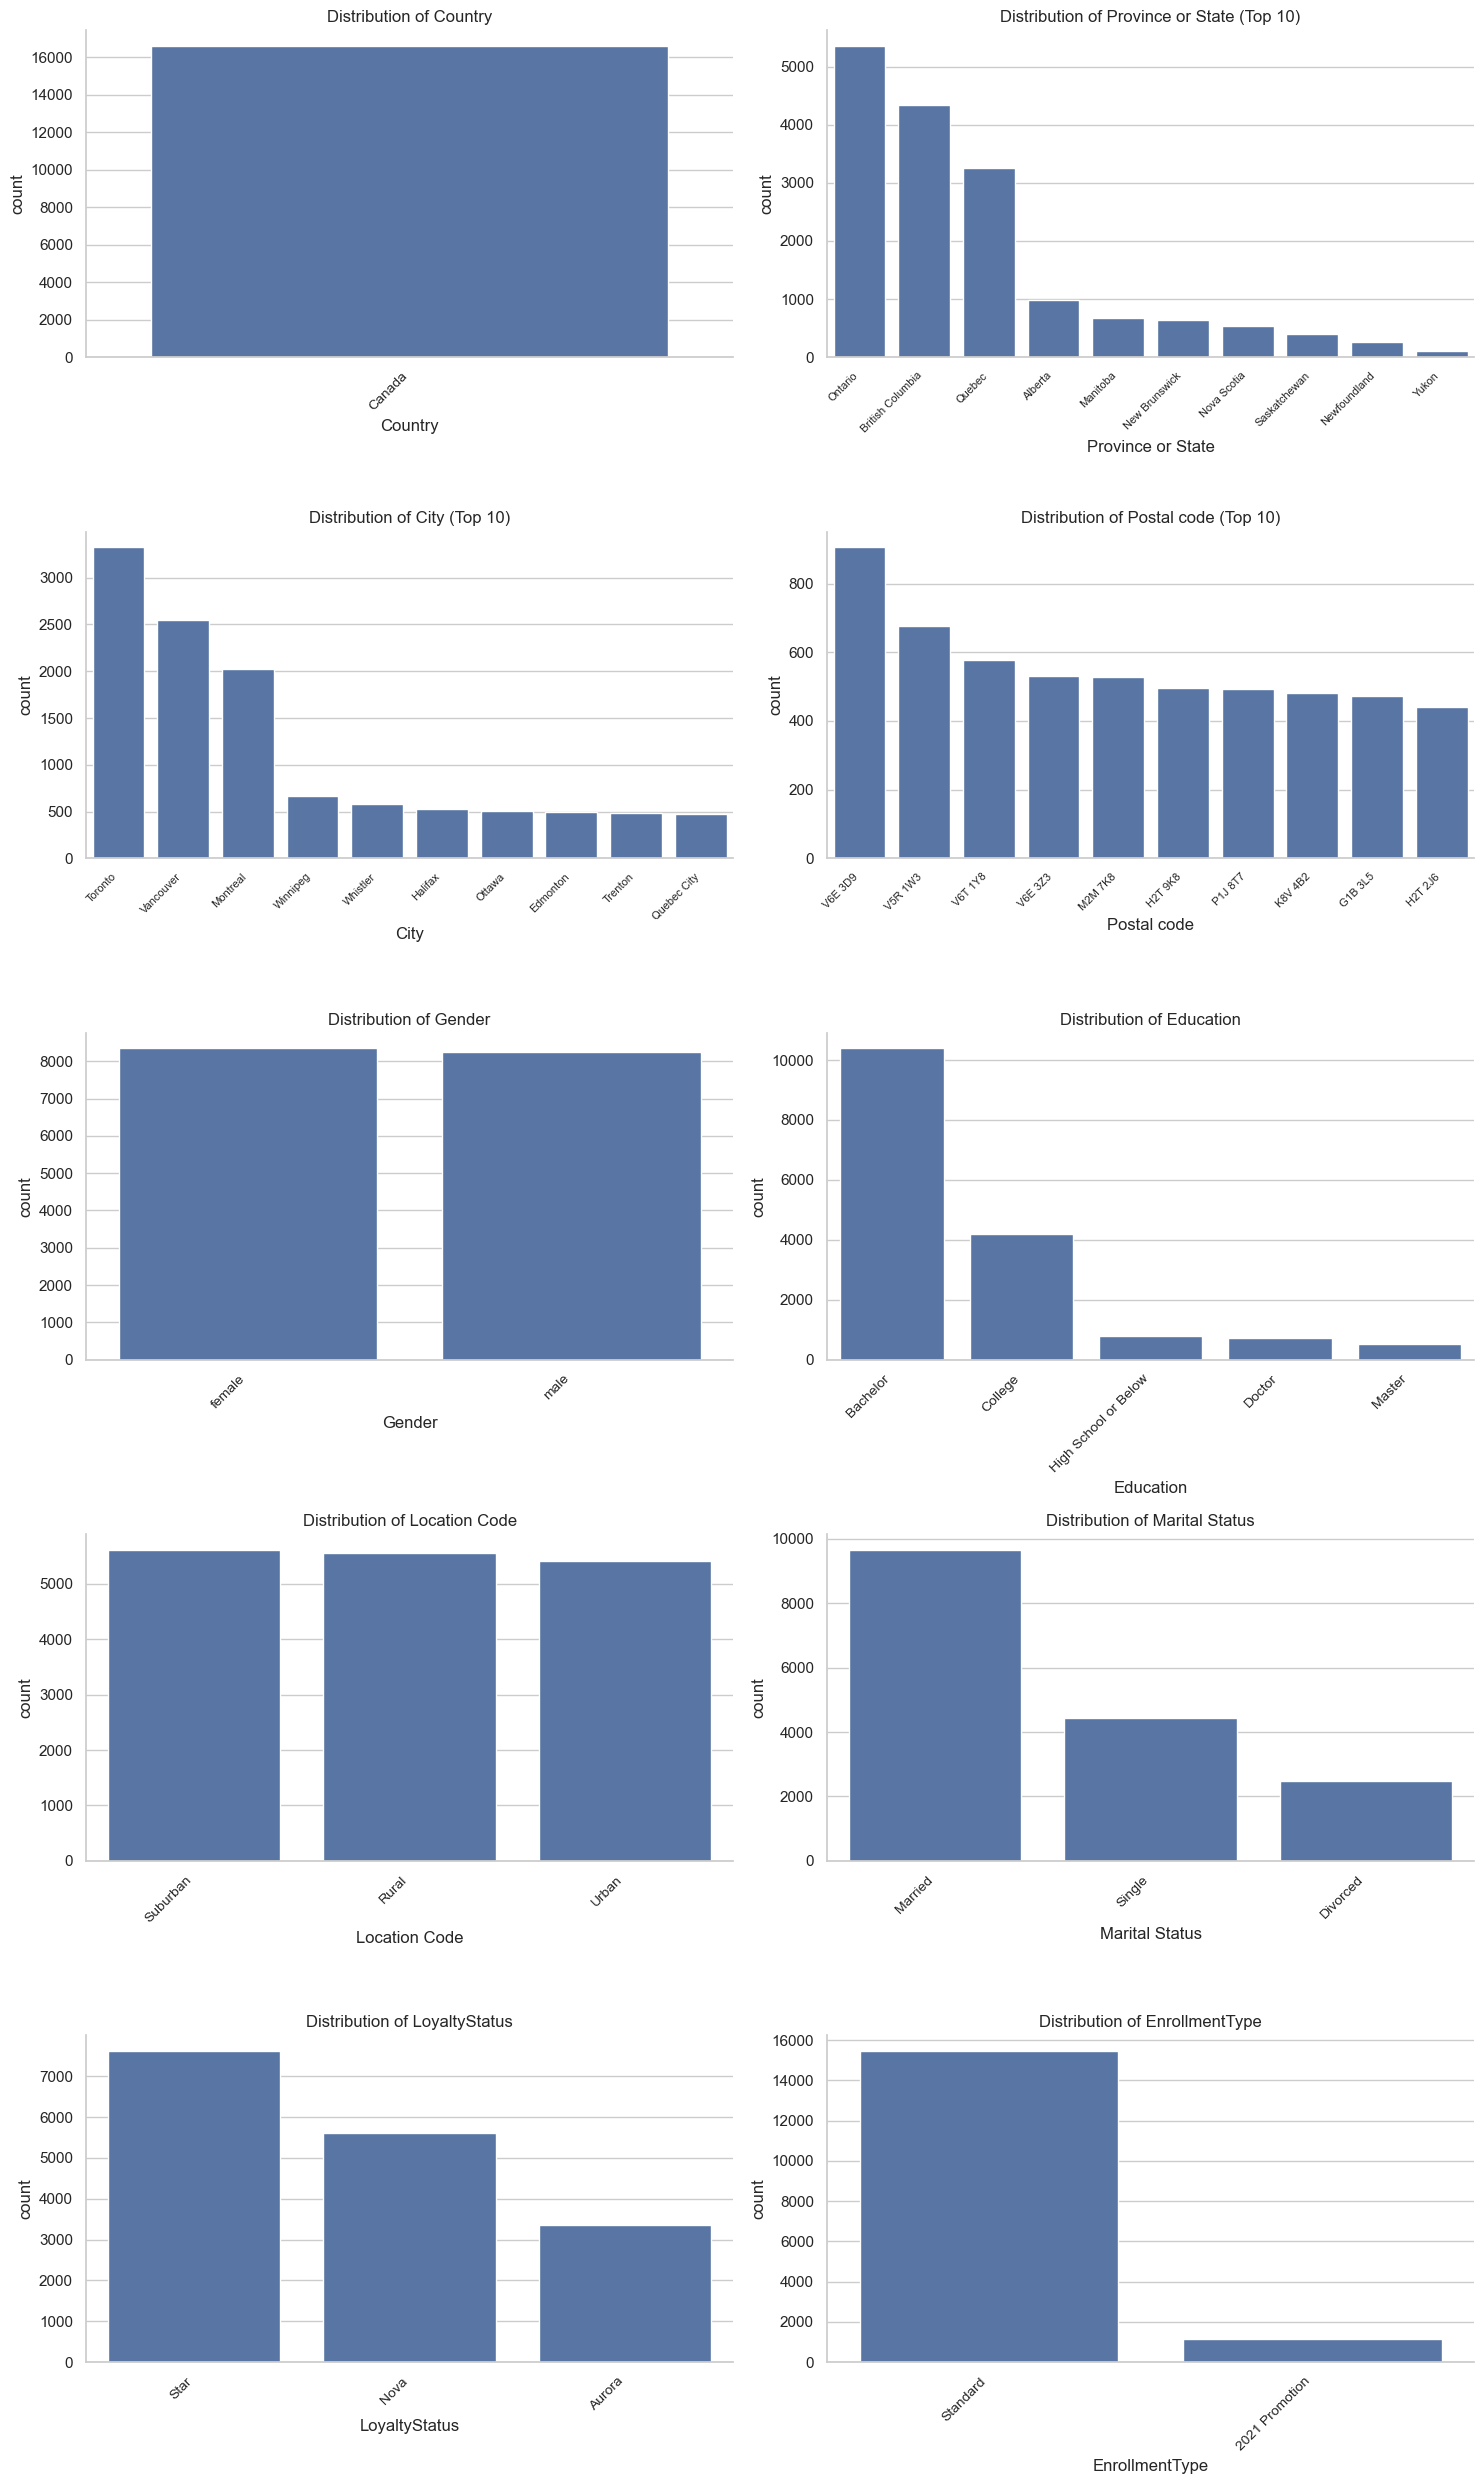

In [515]:
# Grid Layout for Categorical Features
n_cols = 2
n_rows = math.ceil(len(customers_cat.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for i, col in enumerate(customers_cat.columns):
    ax = axes[i]
    value_counts = customers_cat[col].value_counts(dropna=False)

    # Limit number of categories for readability
    max_categories = 10
    if len(value_counts) > max_categories:
        top_cats = value_counts.head(max_categories)
        data = customers_cat[customers_cat[col].isin(top_cats.index)]
        order = top_cats.index
        ax.set_title(f'Distribution of {col} (Top {max_categories})')
    else:
        data = customers_cat
        order = value_counts.index
        ax.set_title(f'Distribution of {col}')

    sns.countplot(data=data, x=col, order=order, ax=ax)

    # Rotate and shrink if necessary
    label_count = len(order)
    label_size = 10 if label_count <= 6 else 8 if label_count <= 10 else 6
    ax.tick_params(axis='x', labelrotation=45, labelsize=label_size)

    # Right-align for readability
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

# Hide empty axes
for j in range(len(customers_cat.columns), len(axes)):
    fig.delaxes(axes[j])

sns.despine(fig)
plt.tight_layout()
plt.show()


### 4.1.2 Customer EDA - Numerical Features  <a class="anchor" id="Customers-EDA-Numerical"></a>


In [516]:
# Filter for only numerical features
num_columns = customers.select_dtypes(include=np.number).columns.tolist()
customers_num = customers[num_columns]

# Remove Loyalty#, Latitude, Longitude from the list --> they are not useful for EDA
customers_num = customers_num.drop(columns=['Loyalty#', 'Latitude', 'Longitude'], errors='ignore')


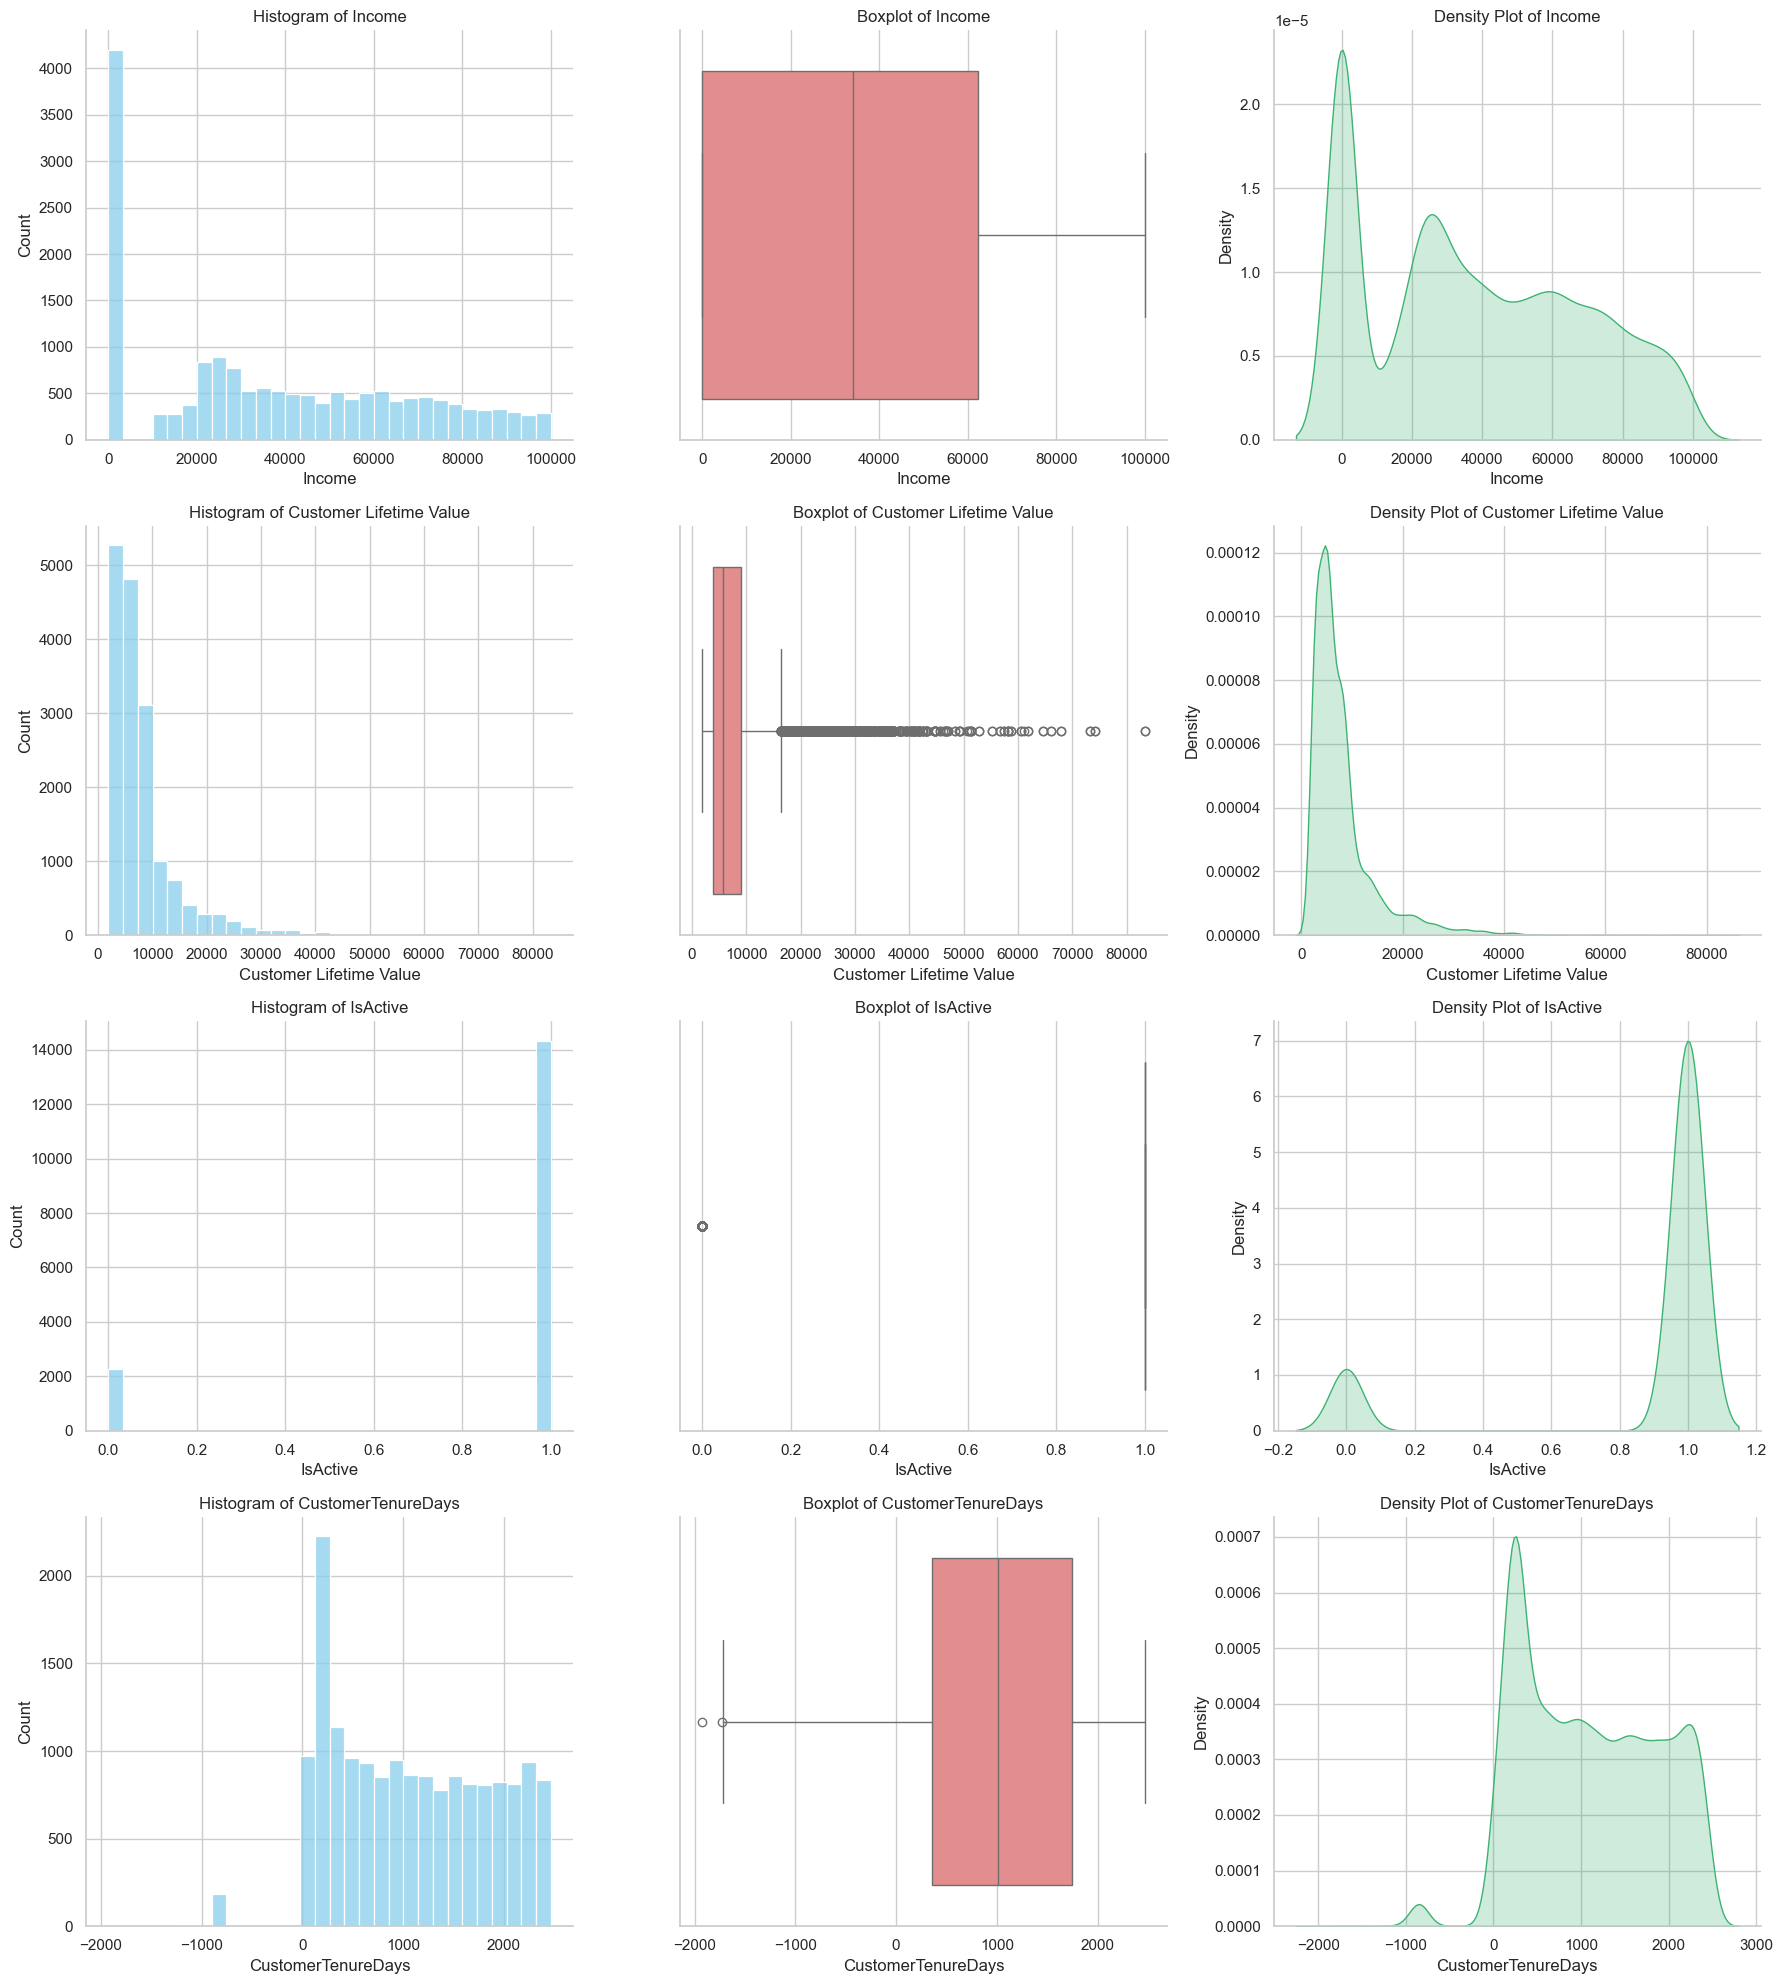

In [517]:
# Create a figure with 3 columns (hist, box, kde)
n_features = len(customers_num.columns)
n_cols = 3
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# If there’s only one feature, make axes 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(customers_num.columns):
    # Histogram
    sns.histplot(customers_num[col], bins=30, kde=False, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=customers_num[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

    # Density plot (KDE)
    sns.kdeplot(customers_num[col].dropna(), ax=axes[i, 2], fill=True, color='mediumseagreen')
    axes[i, 2].set_title(f'Density Plot of {col}')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')

plt.tight_layout()
sns.despine(fig)
plt.show()


### 4.1.2 Customer EDA - Multi-Variate Analysis  <a class="anchor" id="Customers-EDA-Multi-Variate"></a>


We do a multi-variate analysis of the numerical features to see if there are any correlations between them.

- We start with a correlation heatmap to see the correlations between the numerical features.

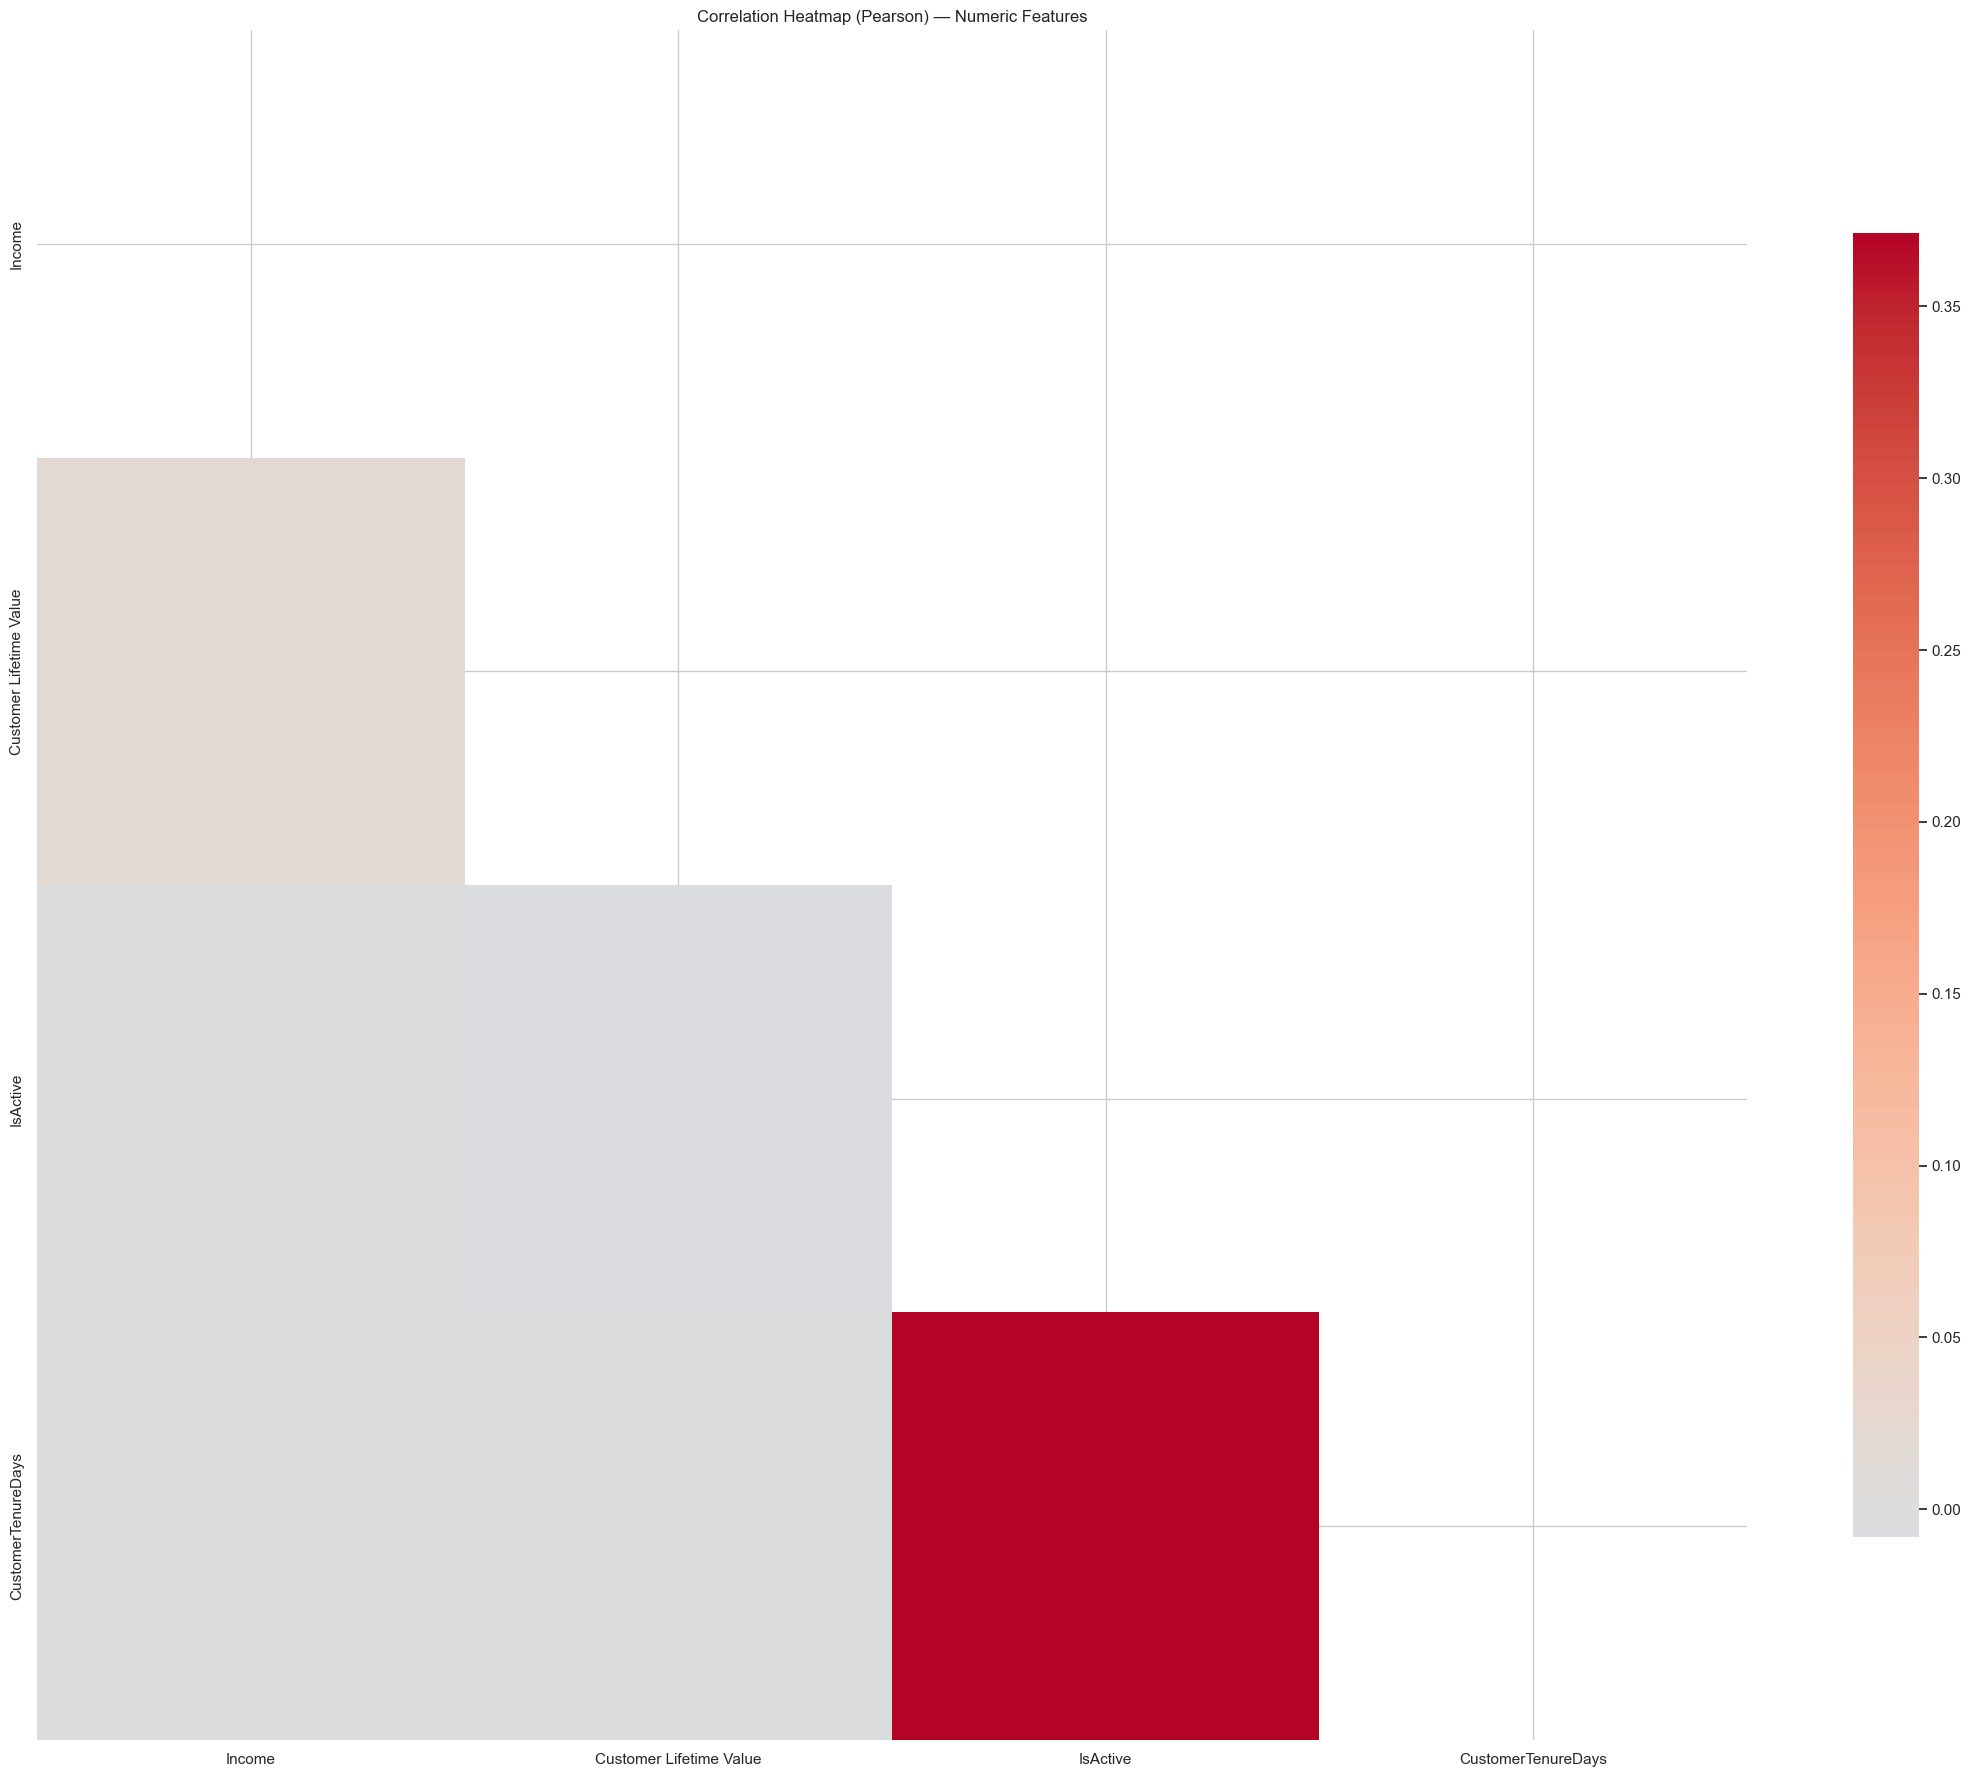

In [518]:
corr = customers_num.corr(method="pearson")

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(min(1.2*len(customers_num), 22), min(1.0*len(customers_num), 18)))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,    # set True if you want numbers (can clutter)
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Correlation Heatmap (Pearson) — Numeric Features")
plt.tight_layout()
plt.show()


below I did a graph alternative to the one above:

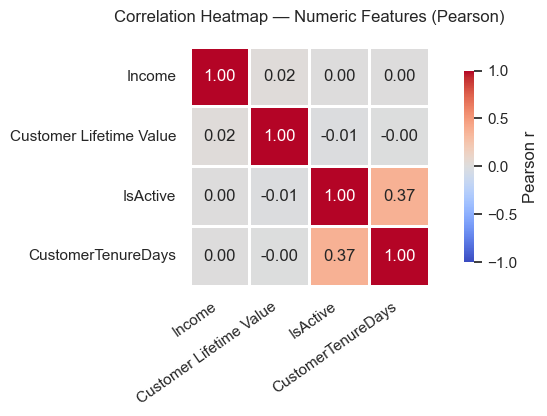

In [519]:
corr = customers_num.corr(method="pearson", numeric_only=True)

fig, ax = plt.subplots(figsize=(6.5, 5.2), constrained_layout=False)

sns.heatmap(
    corr,
    vmin=-1, vmax=1,
    cmap="coolwarm",
    annot=True, fmt=".2f",
    square=True,
    linewidths=1, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r", "pad": 0.08},
    ax=ax
)

# Rotate and right-align x labels to avoid overlap
ax.tick_params(axis="x", labelrotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.set_title("Correlation Heatmap — Numeric Features (Pearson)", pad=18)

# Give extra bottom space for the rotated labels
fig.subplots_adjust(left=0.25, right=0.93, top=0.88, bottom=0.42)

plt.show()

#### 4.1.2.1 Income Analysis

##### Zero Income Analysis

In [520]:
zero_income = customers[customers["Income"] == 0]
"""customer with income = 0"""

'customer with income = 0'

In [521]:
print("=== Gender ===")
print(zero_income["Gender"].value_counts())
print("\n=== Marital Status ===")
print(zero_income["Marital Status"].value_counts())
print("\n=== Education ===")
print(zero_income["Education"].value_counts())

=== Gender ===
Gender
male      2137
female    2061
Name: count, dtype: int64

=== Marital Status ===
Marital Status
Single      2403
Married     1425
Divorced     370
Name: count, dtype: int64

=== Education ===
Education
College    4198
Name: count, dtype: int64


In [522]:
print("=== Location Code ===")
print(zero_income["Location Code"].value_counts())
print("\n=== EnrollmentType ===")
print(zero_income["EnrollmentType"].value_counts())
print("\n=== LoyaltyStatus ===")
print(zero_income["LoyaltyStatus"].value_counts())

=== Location Code ===
Location Code
Rural       1422
Urban       1406
Suburban    1370
Name: count, dtype: int64

=== EnrollmentType ===
EnrollmentType
Standard          3913
2021 Promotion     285
Name: count, dtype: int64

=== LoyaltyStatus ===
LoyaltyStatus
Star      2096
Nova      1319
Aurora     783
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1366238634.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1366238634.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1366238634.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1366238634.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

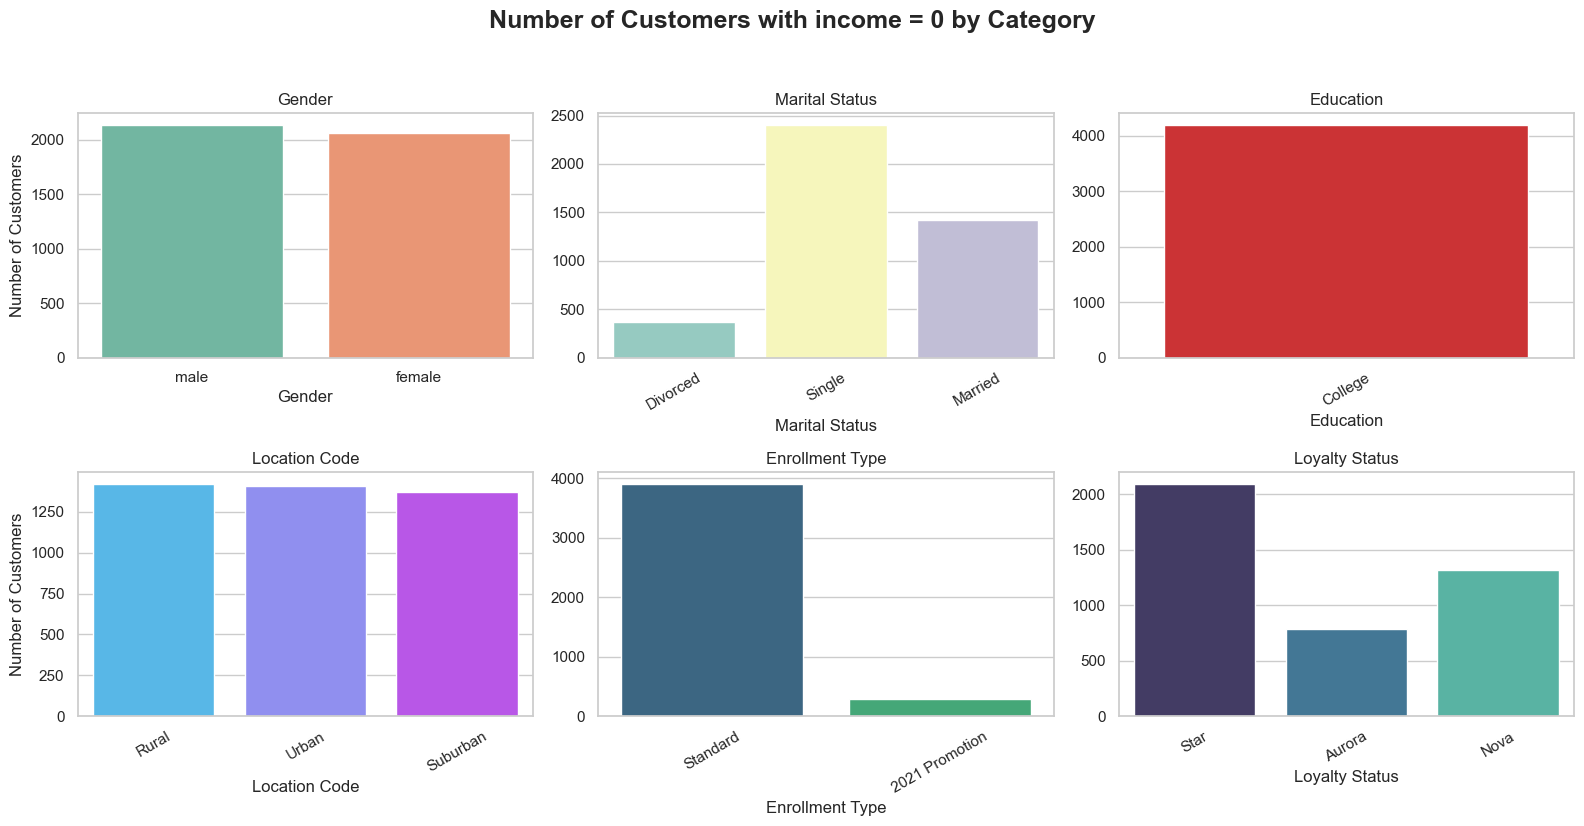

In [523]:
# Set style
sns.set(style="whitegrid")

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Number of customers by Gender
sns.countplot(data=zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

# Number of customers by Marital Status
sns.countplot(data=zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis='x', rotation=30)

# Number of customers by Education
sns.countplot(data=zero_income, x="Education", palette="Set1", ax=axes[0, 2])
axes[0, 2].set_title("Education")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("")
axes[0, 2].tick_params(axis='x', rotation=30)

# Number of customers by Location Code
sns.countplot(data=zero_income, x="Location Code", palette="cool", ax=axes[1, 0])
axes[1, 0].set_title("Location Code")
axes[1, 0].set_xlabel("Location Code")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of customers by Enrollment Type
sns.countplot(data=zero_income, x="EnrollmentType", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Enrollment Type")
axes[1, 1].set_xlabel("Enrollment Type")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis='x', rotation=30)

# Number of customers by Loyalty Status
sns.countplot(data=zero_income, x="LoyaltyStatus", palette="mako", ax=axes[1, 2])
axes[1, 2].set_title("Loyalty Status")
axes[1, 2].set_xlabel("Loyalty Status")
axes[1, 2].set_ylabel("")
axes[1, 2].tick_params(axis='x', rotation=30)

# Add general title
fig.suptitle("Number of Customers with income = 0 by Category", fontsize=18, fontweight='bold', y=1.03)

# Adjust layout
plt.tight_layout()
plt.show()

In [524]:
(customers.loc[customers["Education"] == "College", "Income"] == 0).all()

np.False_

For the analysis done above we can conclude that customer with income = 0:  
    - All have a education degree = College (the lowest one in our dataset). We can also see that all college customer have an income of 0  
    - The majority are Single  
    - Almost all have a Standard Enrollment Type

In [525]:
print("\n=== City ===")
print(zero_income["City"].value_counts())


=== City ===
City
Toronto           831
Vancouver         652
Montreal          538
Winnipeg          172
Whistler          160
Trenton           129
Ottawa            128
Edmonton          127
Halifax           116
Victoria          105
Regina            104
Kingston          103
Fredericton       100
Quebec City       100
Dawson Creek       98
Tremblant          89
Hull               88
West Vancouver     74
Sudbury            68
Thunder Bay        67
St. John's         65
Calgary            52
London             47
Moncton            46
Banff              44
Whitehorse         31
Peace River        23
Kelowna            22
Charlottetown      19
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\99857658.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




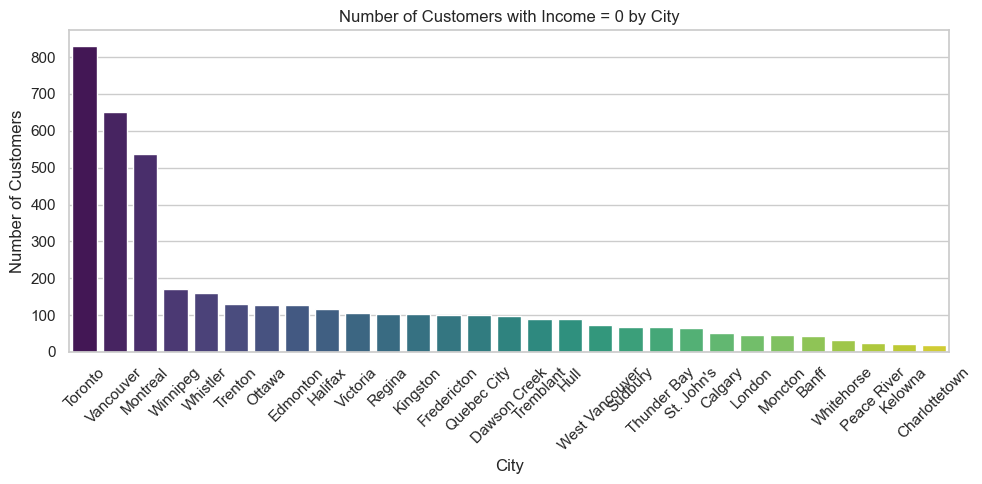

In [526]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = zero_income["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create figure
plt.figure(figsize=(10, 5))

# Bar chart: Number of customers by City
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers with Income = 0 by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distibution by City is completly align with the one where we consider all types of income. Nothing to add here.

In [527]:
print("\n=== IsActive ===")
print(zero_income["IsActive"].value_counts())


=== IsActive ===
IsActive
1    3623
0     575
Name: count, dtype: int64


The Majority of customer with income = 0 are still active

Regarding customers with income = 0, the data seems valid

##### Non Zero Income Analysis

In [528]:
non_zero_income = customers[customers["Income"] != 0]
"""customer with income different from 0"""

'customer with income different from 0'

In [529]:
print("=== Gender ===")
print(non_zero_income["Gender"].value_counts())
print("\n=== Marital Status ===")
print(non_zero_income["Marital Status"].value_counts())
print("\n=== Education ===")
print(non_zero_income["Education"].value_counts())

=== Gender ===
Gender
female    6285
male      6111
Name: count, dtype: int64

=== Marital Status ===
Marital Status
Married     8233
Divorced    2117
Single      2046
Name: count, dtype: int64

=== Education ===
Education
Bachelor                10386
High School or Below      772
Doctor                    724
Master                    504
College                    10
Name: count, dtype: int64


In [530]:
print("=== Location Code ===")
print(non_zero_income["Location Code"].value_counts())
print("\n=== EnrollmentType ===")
print(non_zero_income["EnrollmentType"].value_counts())
print("\n=== LoyaltyStatus ===")
print(non_zero_income["LoyaltyStatus"].value_counts())

=== Location Code ===
Location Code
Suburban    4246
Rural       4142
Urban       4008
Name: count, dtype: int64

=== EnrollmentType ===
EnrollmentType
Standard          11543
2021 Promotion      853
Name: count, dtype: int64

=== LoyaltyStatus ===
LoyaltyStatus
Star      5522
Nova      4292
Aurora    2582
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3732720629.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3732720629.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3732720629.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3732720629.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

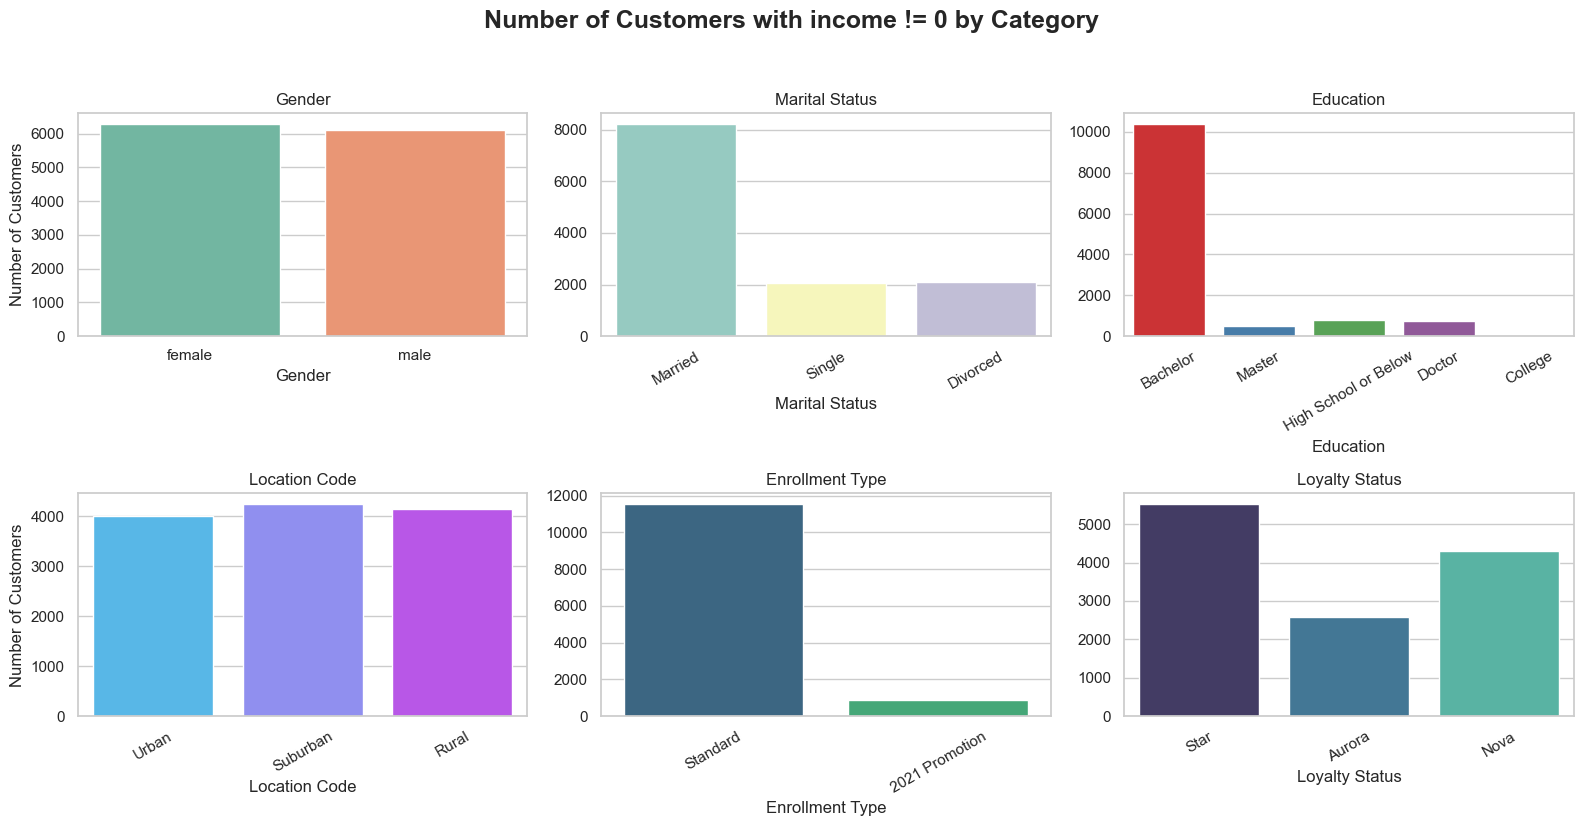

In [531]:
# Set style
sns.set(style="whitegrid")

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Number of customers by Gender
sns.countplot(data=non_zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

# Number of customers by Marital Status
sns.countplot(data=non_zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis='x', rotation=30)

# Number of customers by Education
sns.countplot(data=non_zero_income, x="Education", palette="Set1", ax=axes[0, 2])
axes[0, 2].set_title("Education")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("")
axes[0, 2].tick_params(axis='x', rotation=30)

# Number of customers by Location Code
sns.countplot(data=non_zero_income, x="Location Code", palette="cool", ax=axes[1, 0])
axes[1, 0].set_title("Location Code")
axes[1, 0].set_xlabel("Location Code")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of customers by Enrollment Type
sns.countplot(data=non_zero_income, x="EnrollmentType", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Enrollment Type")
axes[1, 1].set_xlabel("Enrollment Type")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis='x', rotation=30)

# Number of customers by Loyalty Status
sns.countplot(data=non_zero_income, x="LoyaltyStatus", palette="mako", ax=axes[1, 2])
axes[1, 2].set_title("Loyalty Status")
axes[1, 2].set_xlabel("Loyalty Status")
axes[1, 2].set_ylabel("")
axes[1, 2].tick_params(axis='x', rotation=30)

# Add general title
fig.suptitle("Number of Customers with income != 0 by Category", fontsize=18, fontweight='bold', y=1.03)

# Adjust layout
plt.tight_layout()
plt.show()

In [532]:
print("\n=== City ===")
print(non_zero_income["City"].value_counts())


=== City ===
City
Toronto           2495
Vancouver         1899
Montreal          1491
Winnipeg           494
Whistler           419
Halifax            413
Ottawa             379
Quebec City        375
Edmonton           371
Trenton            354
Dawson Creek       339
Fredericton        321
Tremblant          301
Regina             300
Kingston           294
Victoria           277
Hull               267
West Vancouver     234
St. John's         188
Thunder Bay        184
Moncton            167
Sudbury            156
Banff              142
Calgary            140
London             125
Peace River         90
Whitehorse          77
Kelowna             57
Charlottetown       47
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3034325704.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




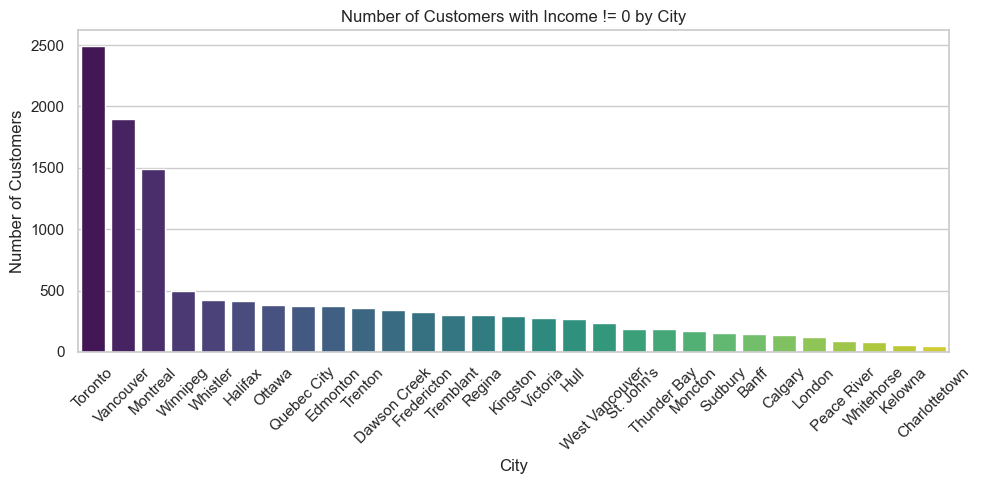

In [533]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = non_zero_income["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create figure
plt.figure(figsize=(10, 5))

# Bar chart: Number of customers by City
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers with Income != 0 by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distibution by City is completly align with the one where we consider all types of income. Nothing to add here.

In [534]:
print("\n=== IsActive ===")
print(non_zero_income["IsActive"].value_counts())


=== IsActive ===
IsActive
1    10704
0     1692
Name: count, dtype: int64


The Majority of customer with income = 0 are still active

Regarding customers with income != 0, the data seems valid

##### Levels of Income by Gender

In [535]:
customers.groupby('Gender')['Income'].mean()

Gender
female    38033.716977
male      37442.834082
Name: Income, dtype: float64

In [536]:
customers.groupby('Gender')['Income'].median()

Gender
female    34161.0
male      34112.0
Name: Income, dtype: float64

In [537]:
customers.groupby('Gender')['Income'].agg(['min', 'max'])

,min,max
Gender,,
female,0.0,99981.0
male,0.0,99981.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\494790023.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




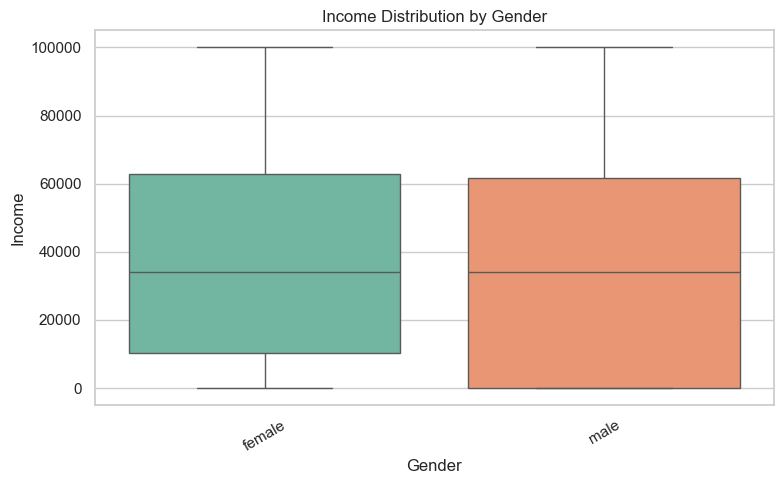

In [538]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="Gender", y="Income", palette="Set2")

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between gender.

##### Levels of Income by Education

In [539]:
customers.groupby('Education')['Income'].mean()

Education
Bachelor                56359.408942
College                     0.000000
Doctor                  20070.616022
High School or Below    20335.269430
Master                  20666.615538
Name: Income, dtype: float64

In [540]:
customers.groupby('Education')['Income'].median()

Education
Bachelor                55579.5
College                     0.0
Doctor                  20179.5
High School or Below    20480.5
Master                  21073.0
Name: Income, dtype: float64

In [541]:
customers.groupby('Education')['Income'].agg(['min', 'max'])

,min,max
Education,,
Bachelor,20009.0,99981.0
College,0.0,0.0
Doctor,10097.0,29981.0
High School or Below,10037.0,29957.0
Master,10180.0,29692.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\446967427.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




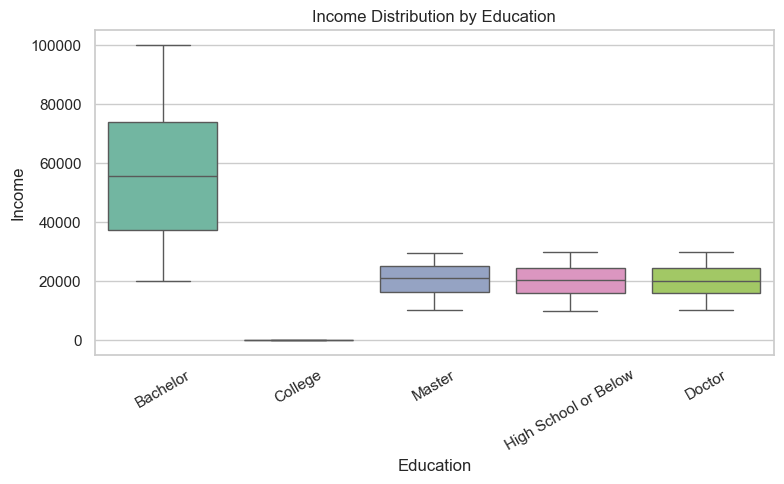

In [542]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="Education", y="Income", palette="Set2")

plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Levels of Income by Martial Status

In [543]:
customers.groupby('Marital Status')['Income'].mean()

Marital Status
Divorced    40781.406514
Married     43828.457599
Single      22812.402837
Name: Income, dtype: float64

In [544]:
customers.groupby('Marital Status')['Income'].median()

Marital Status
Divorced    36791.0
Married     41459.0
Single          0.0
Name: Income, dtype: float64

In [545]:
customers.groupby('Marital Status')['Income'].agg(['min', 'max'])

,min,max
Marital Status,,
Divorced,0.0,99875.0
Married,0.0,99981.0
Single,0.0,99816.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3703766363.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




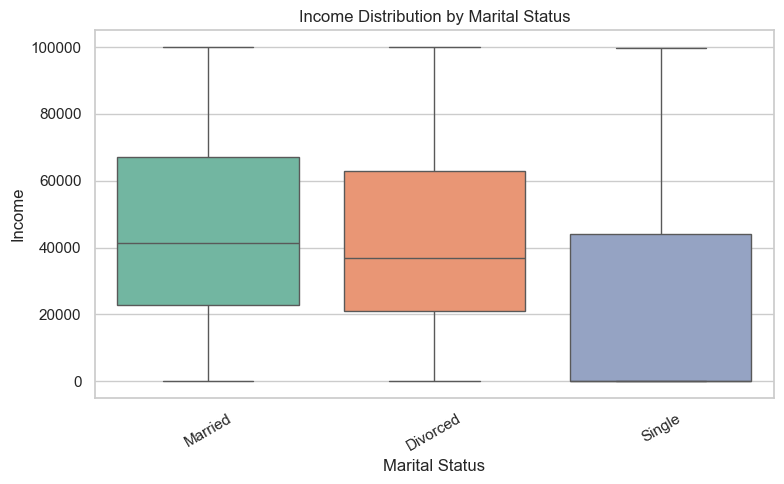

In [546]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="Marital Status", y="Income", palette="Set2")

plt.title("Income Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Levels of Income by Location Code

In [547]:
customers.groupby('Location Code')['Income'].mean()

Location Code
Rural       37674.255174
Suburban    37975.735200
Urban       37563.095212
Name: Income, dtype: float64

In [548]:
customers.groupby('Location Code')['Income'].median()

Location Code
Rural       33837.0
Suburban    34537.0
Urban       33992.0
Name: Income, dtype: float64

In [549]:
customers.groupby('Location Code')['Income'].agg(['min', 'max'])

,min,max
Location Code,,
Rural,0.0,99981.0
Suburban,0.0,99981.0
Urban,0.0,99960.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3187076046.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




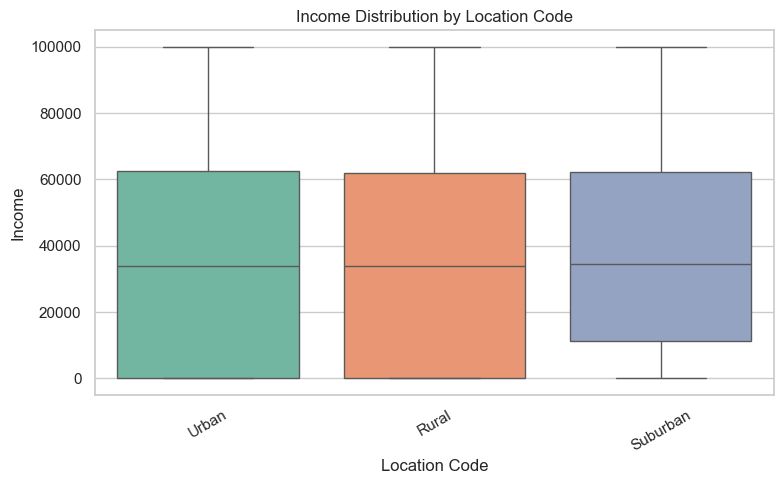

In [550]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="Location Code", y="Income", palette="Set2")

plt.title("Income Distribution by Location Code")
plt.xlabel("Location Code")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Levels of Income by Enrollment Type

In [551]:
customers.groupby('EnrollmentType')['Income'].mean()

EnrollmentType
2021 Promotion    37802.535149
Standard          37735.375486
Name: Income, dtype: float64

In [552]:
customers.groupby('EnrollmentType')['Income'].median()

EnrollmentType
2021 Promotion    34990.0
Standard          34103.5
Name: Income, dtype: float64

In [553]:
customers.groupby('EnrollmentType')['Income'].agg(['min', 'max'])

,min,max
EnrollmentType,,
2021 Promotion,0.0,99960.0
Standard,0.0,99981.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3181369662.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




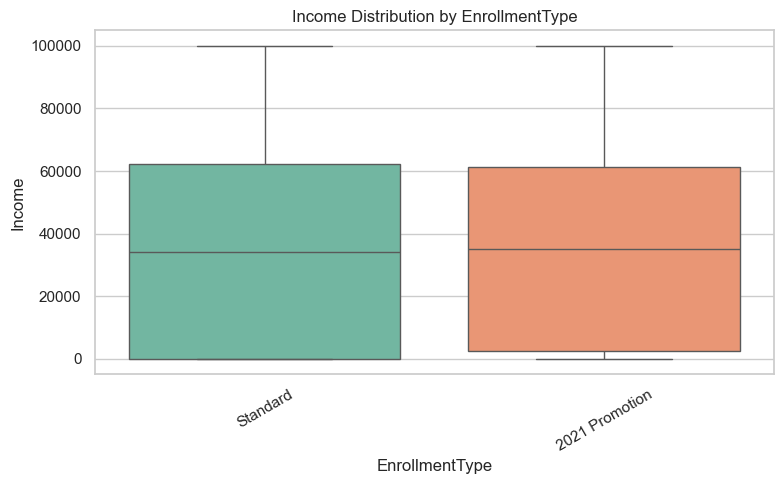

In [554]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="EnrollmentType", y="Income", palette="Set2")

plt.title("Income Distribution by EnrollmentType")
plt.xlabel("EnrollmentType")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Level of Income by Loyalty Status

In [555]:
customers.groupby('LoyaltyStatus')['Income'].mean()

LoyaltyStatus
Aurora    40101.387519
Nova      38946.834789
Star      35802.932614
Name: Income, dtype: float64

In [556]:
customers.groupby('LoyaltyStatus')['Income'].median()

LoyaltyStatus
Aurora    38210.0
Nova      36094.0
Star      30817.0
Name: Income, dtype: float64

In [557]:
customers.groupby('LoyaltyStatus')['Income'].agg(['min', 'max'])

,min,max
LoyaltyStatus,,
Aurora,0.0,99960.0
Nova,0.0,99981.0
Star,0.0,99961.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3223910001.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




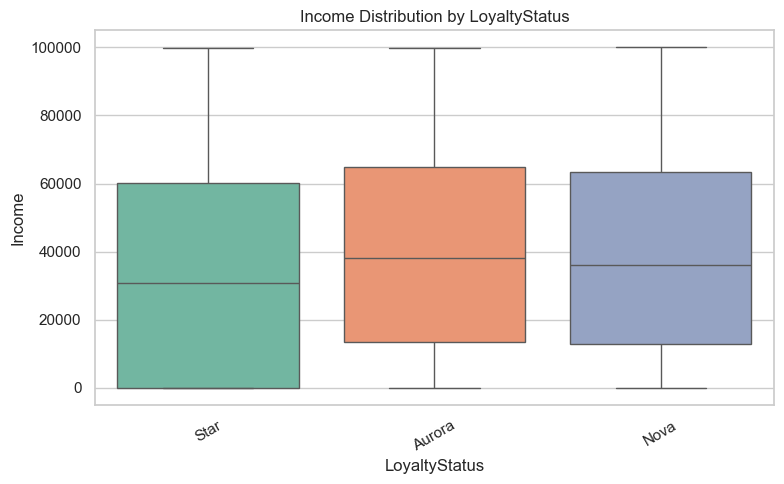

In [558]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers, x="LoyaltyStatus", y="Income", palette="Set2")

plt.title("Income Distribution by LoyaltyStatus")
plt.xlabel("LoyaltyStatus")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Levels of Income by CustomerLifetimeValue

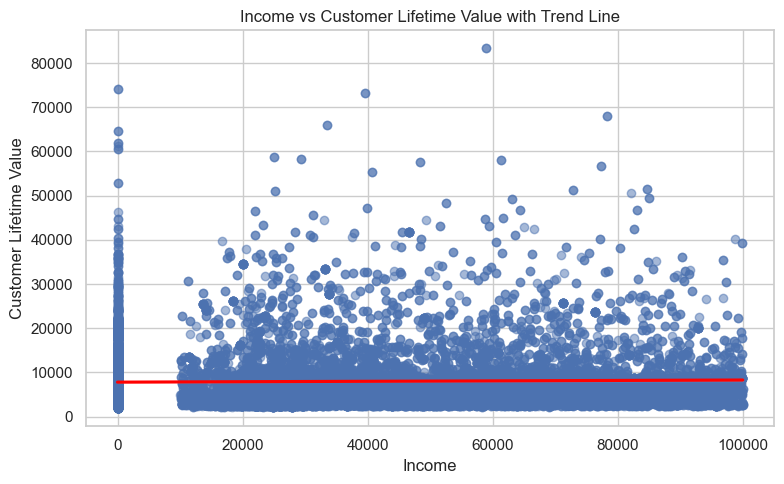

In [559]:
plt.figure(figsize=(8, 5))
sns.regplot(data=customers, x="Income", y="Customer Lifetime Value", scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Income vs Customer Lifetime Value with Trend Line")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.tight_layout()
plt.show()

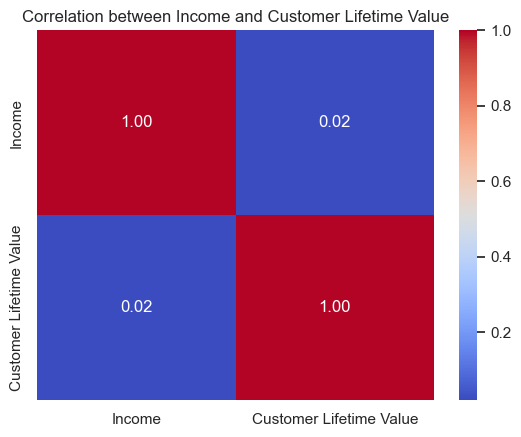

In [560]:
corr = customers[["Income", "Customer Lifetime Value"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Income and Customer Lifetime Value")
plt.show()

There is no correlation between income and CustomerLifeTimeValue

### 4.1.2.2 Gender Analysis

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3110372377.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




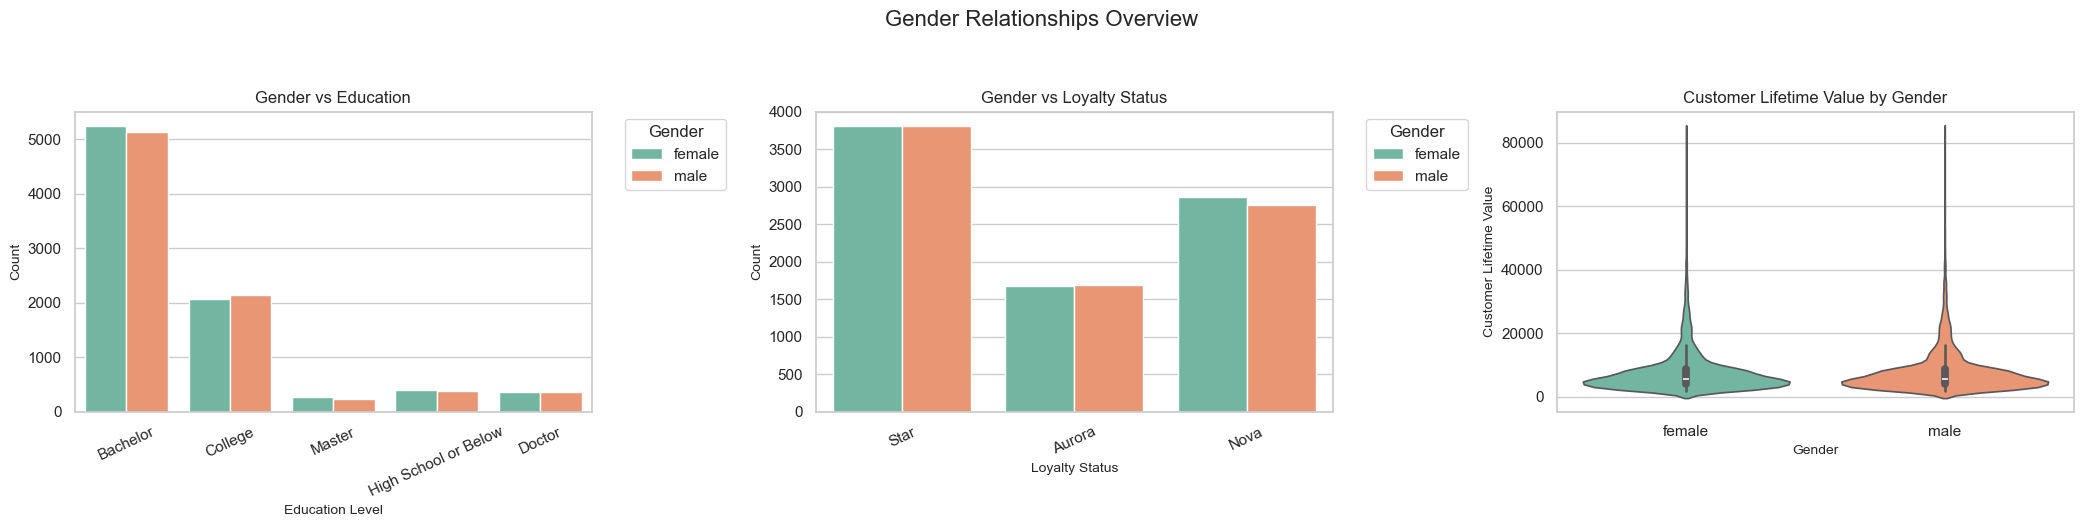

In [561]:
# Define a shared color palette for Gender
gender_palette = sns.color_palette("Set2", n_colors=2)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# 1. Gender vs Education
sns.countplot(
    data=customers,
    x="Education",
    hue="Gender",
    palette=gender_palette,
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_title("Gender vs Education", fontsize=12)
axes[0].set_xlabel("Education Level", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].tick_params(axis="x", labelrotation=25)
axes[0].legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")

# 2. Gender vs LoyaltyStatus
sns.countplot(
    data=customers,
    x="LoyaltyStatus",
    hue="Gender",
    palette=gender_palette,
    edgecolor="white",
    ax=axes[1]
)
axes[1].set_title("Gender vs Loyalty Status", fontsize=12)
axes[1].set_xlabel("Loyalty Status", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].tick_params(axis="x", labelrotation=25)
axes[1].legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")

# 3. Distribution of Customer Lifetime Value by Gender
sns.violinplot(
    data=customers,
    x="Gender",
    y="Customer Lifetime Value",
    palette=gender_palette,
    inner="box",
    ax=axes[2]
)
axes[2].set_title("Customer Lifetime Value by Gender", fontsize=12)
axes[2].set_xlabel("Gender", fontsize=10)
axes[2].set_ylabel("Customer Lifetime Value", fontsize=10)

# Main title for the entire figure
fig.suptitle("Gender Relationships Overview", fontsize=16, y=1.05)

plt.tight_layout()
plt.show()


### 4.1.2.3 Education Analysis

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1610635988.py:36: UserWarning:

The palette list has more values (5) than needed (3), which may not be intended.

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\1610635988.py:58: UserWarning:

The palette list has more values (5) than needed (3), which may not be intended.



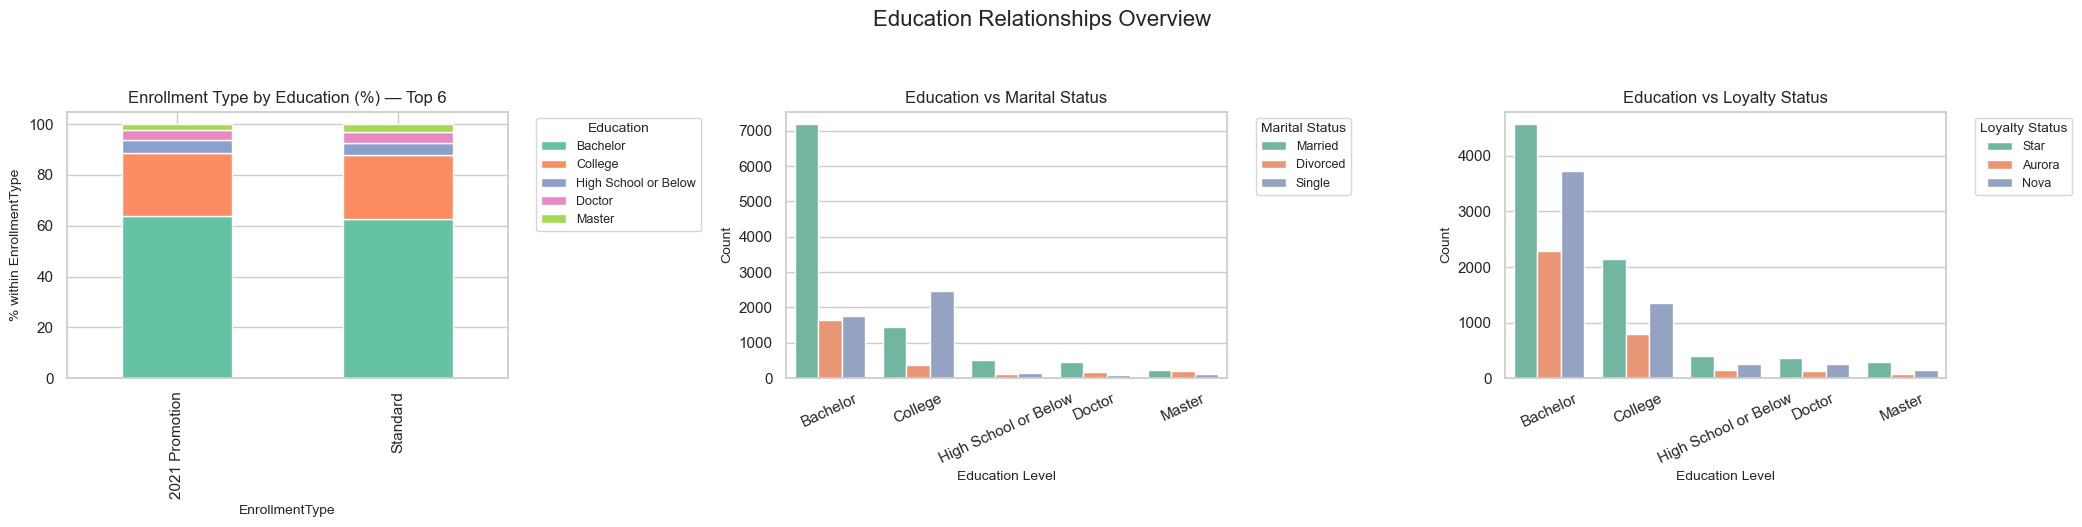

In [562]:
# Create a consistent color palette based on Education categories
edu_order = customers_original["Education"].value_counts().nlargest(6).index.tolist()
shared_palette = sns.color_palette("Set2", n_colors=len(edu_order))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# 1. EnrollmentType by Education
if set(["EnrollmentType", "Education"]).issubset(customers.columns):
    top_edu = customers["Education"].value_counts().nlargest(6).index
    sub = customers[customers["Education"].isin(top_edu)].copy()
    ctab = pd.crosstab(sub["EnrollmentType"], sub["Education"], normalize="index") * 100
    ctab = ctab[edu_order]  # ensure same education order as other plots
    ctab.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        legend=True,
        color=shared_palette,
        edgecolor="white"
    )
    axes[0].set_title("Enrollment Type by Education (%) — Top 6", fontsize=12)
    axes[0].set_ylabel("% within EnrollmentType", fontsize=10)
    axes[0].set_xlabel("EnrollmentType", fontsize=10)
    axes[0].legend(
        title="Education",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=9,
        title_fontsize=10
    )
else:
    axes[0].text(0.5, 0.5, "Columns not found", ha="center", va="center")
    axes[0].axis("off")

# 2. Education vs Marital Status
sns.countplot(
    data=customers_original,
    x="Education",
    hue="Marital Status",
    palette=shared_palette,
    edgecolor="white",
    order=edu_order,
    ax=axes[1]
)
axes[1].set_title("Education vs Marital Status", fontsize=12)
axes[1].set_xlabel("Education Level", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].tick_params(axis="x", labelrotation=25)
axes[1].legend(
    title="Marital Status",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)

# 3. Education vs Loyalty Status
sns.countplot(
    data=customers_original,
    x="Education",
    hue="LoyaltyStatus",
    palette=shared_palette,
    edgecolor="white",
    order=edu_order,
    ax=axes[2]
)
axes[2].set_title("Education vs Loyalty Status", fontsize=12)
axes[2].set_xlabel("Education Level", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].tick_params(axis="x", labelrotation=25)
axes[2].legend(
    title="Loyalty Status",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)

# Add a main title across all three
fig.suptitle("Education Relationships Overview", fontsize=16, y=1.05)

plt.tight_layout()
plt.show()


### 4.1.2.4 Loyalty Status Analysis

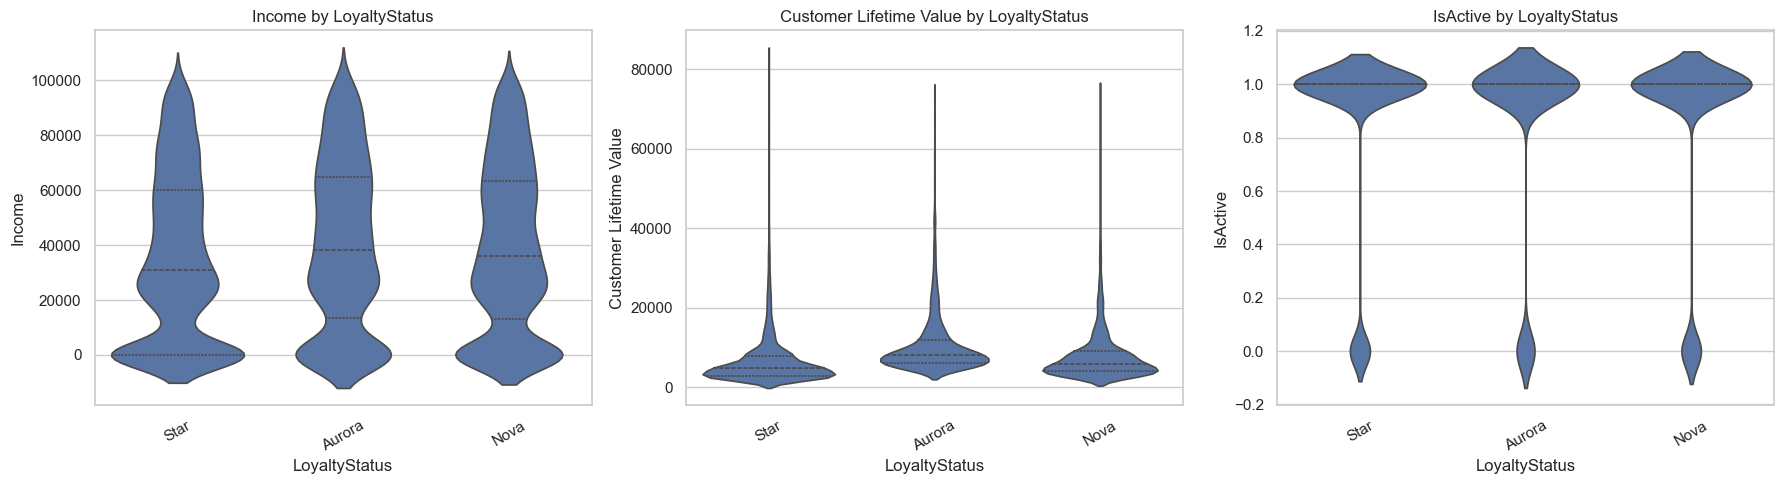

In [563]:
# Numeric vs Categorical — box/violin by LoyaltyStatus

cat_for_group = "LoyaltyStatus"
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


### 4.1.2.5 Marital Status Analysis

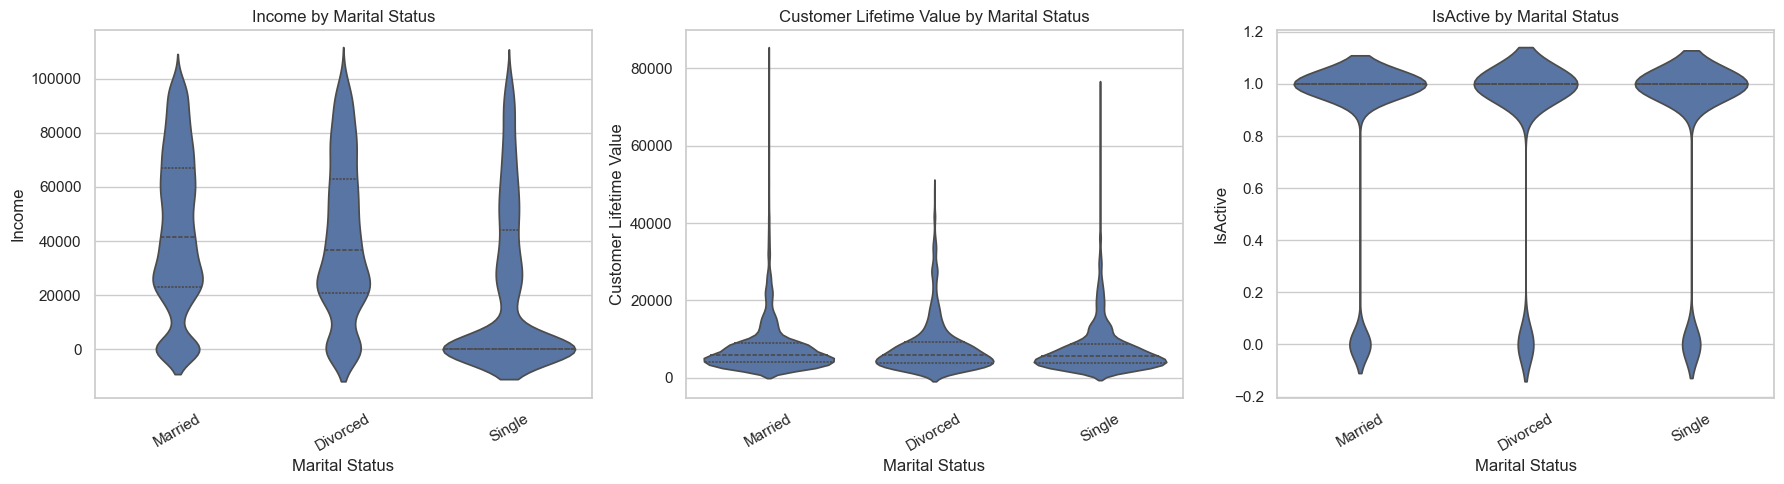

In [564]:
# Numeric vs Categorical — box/violin by Marital Status

cat_for_group = "Marital Status"   
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


### 4.1.2.6 Location Code Analysis

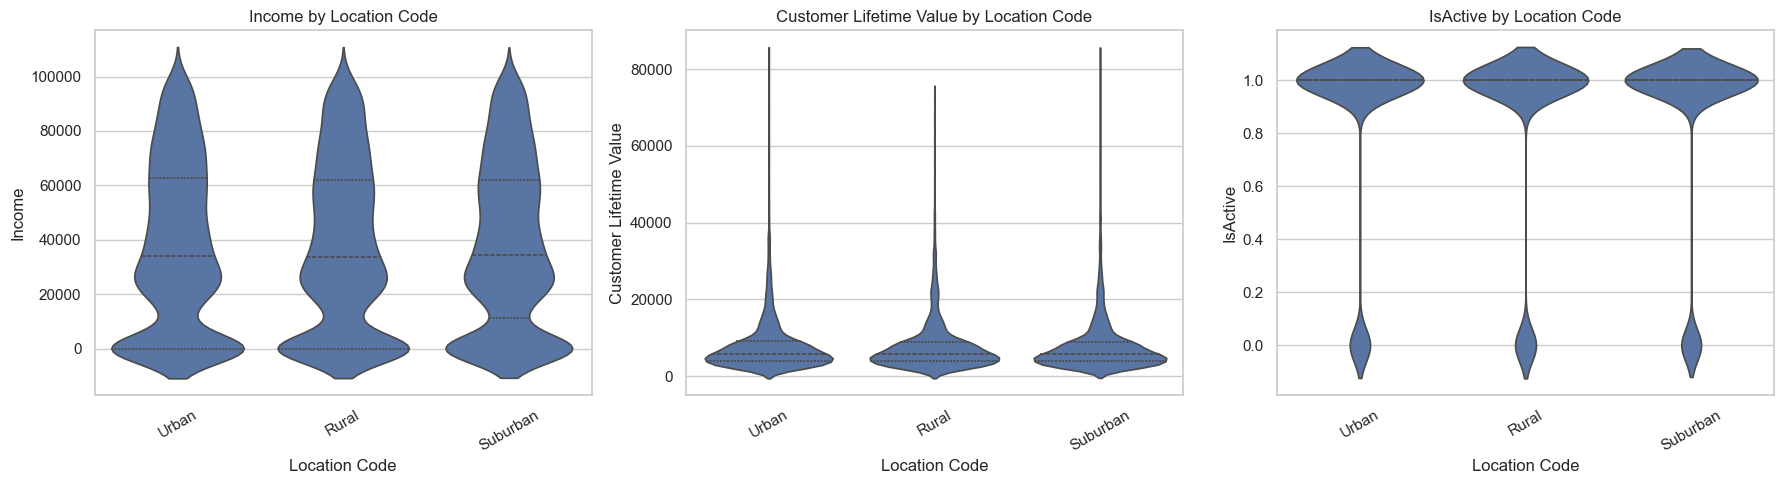

In [565]:
# Numeric vs Categorical — box/violin by Location Code

cat_for_group = "Location Code" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


### 4.1.2.7 Enrollment Type Analysis

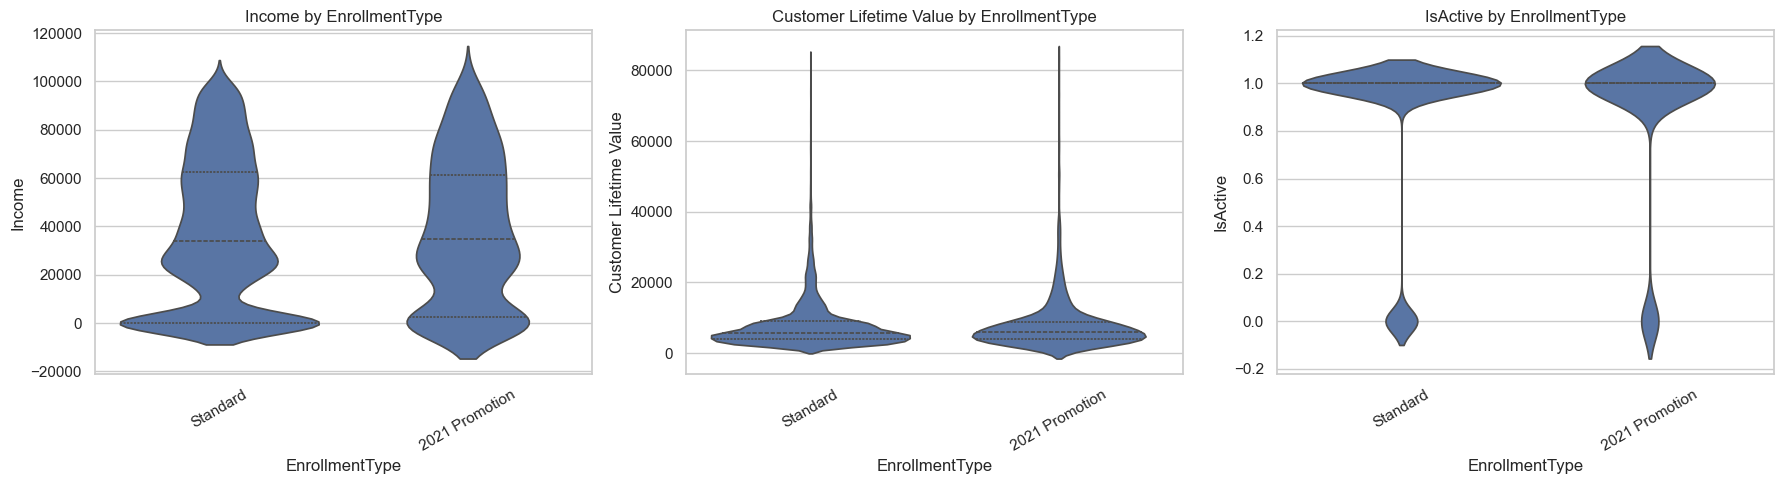

In [566]:
# Numeric vs Categorical — box/violin by EnrollmentType

cat_for_group = "EnrollmentType" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


## 5.2 Flights EDA  <a class="anchor" id="Flights-EDA"></a>



We only have numerical features and one pandas datetime feature in the flights dataset. First we filter for the numerical features and do the EDA on them. 

###  5.2.1 Flights EDA - Numerical Features  <a class="anchor" id="Flights-EDA"></a>


In [567]:
# Filter for numerical features
num_columns_flights = flights.select_dtypes(include=np.number).columns.tolist()
flights_num = flights[num_columns_flights]

# Remove Loyalty#, Month and Year --> they are not useful for EDA, Month and Year have the same value for all rows
flights_num = flights_num.drop(columns=['Loyalty#', 'Month', 'Year'], errors='ignore')

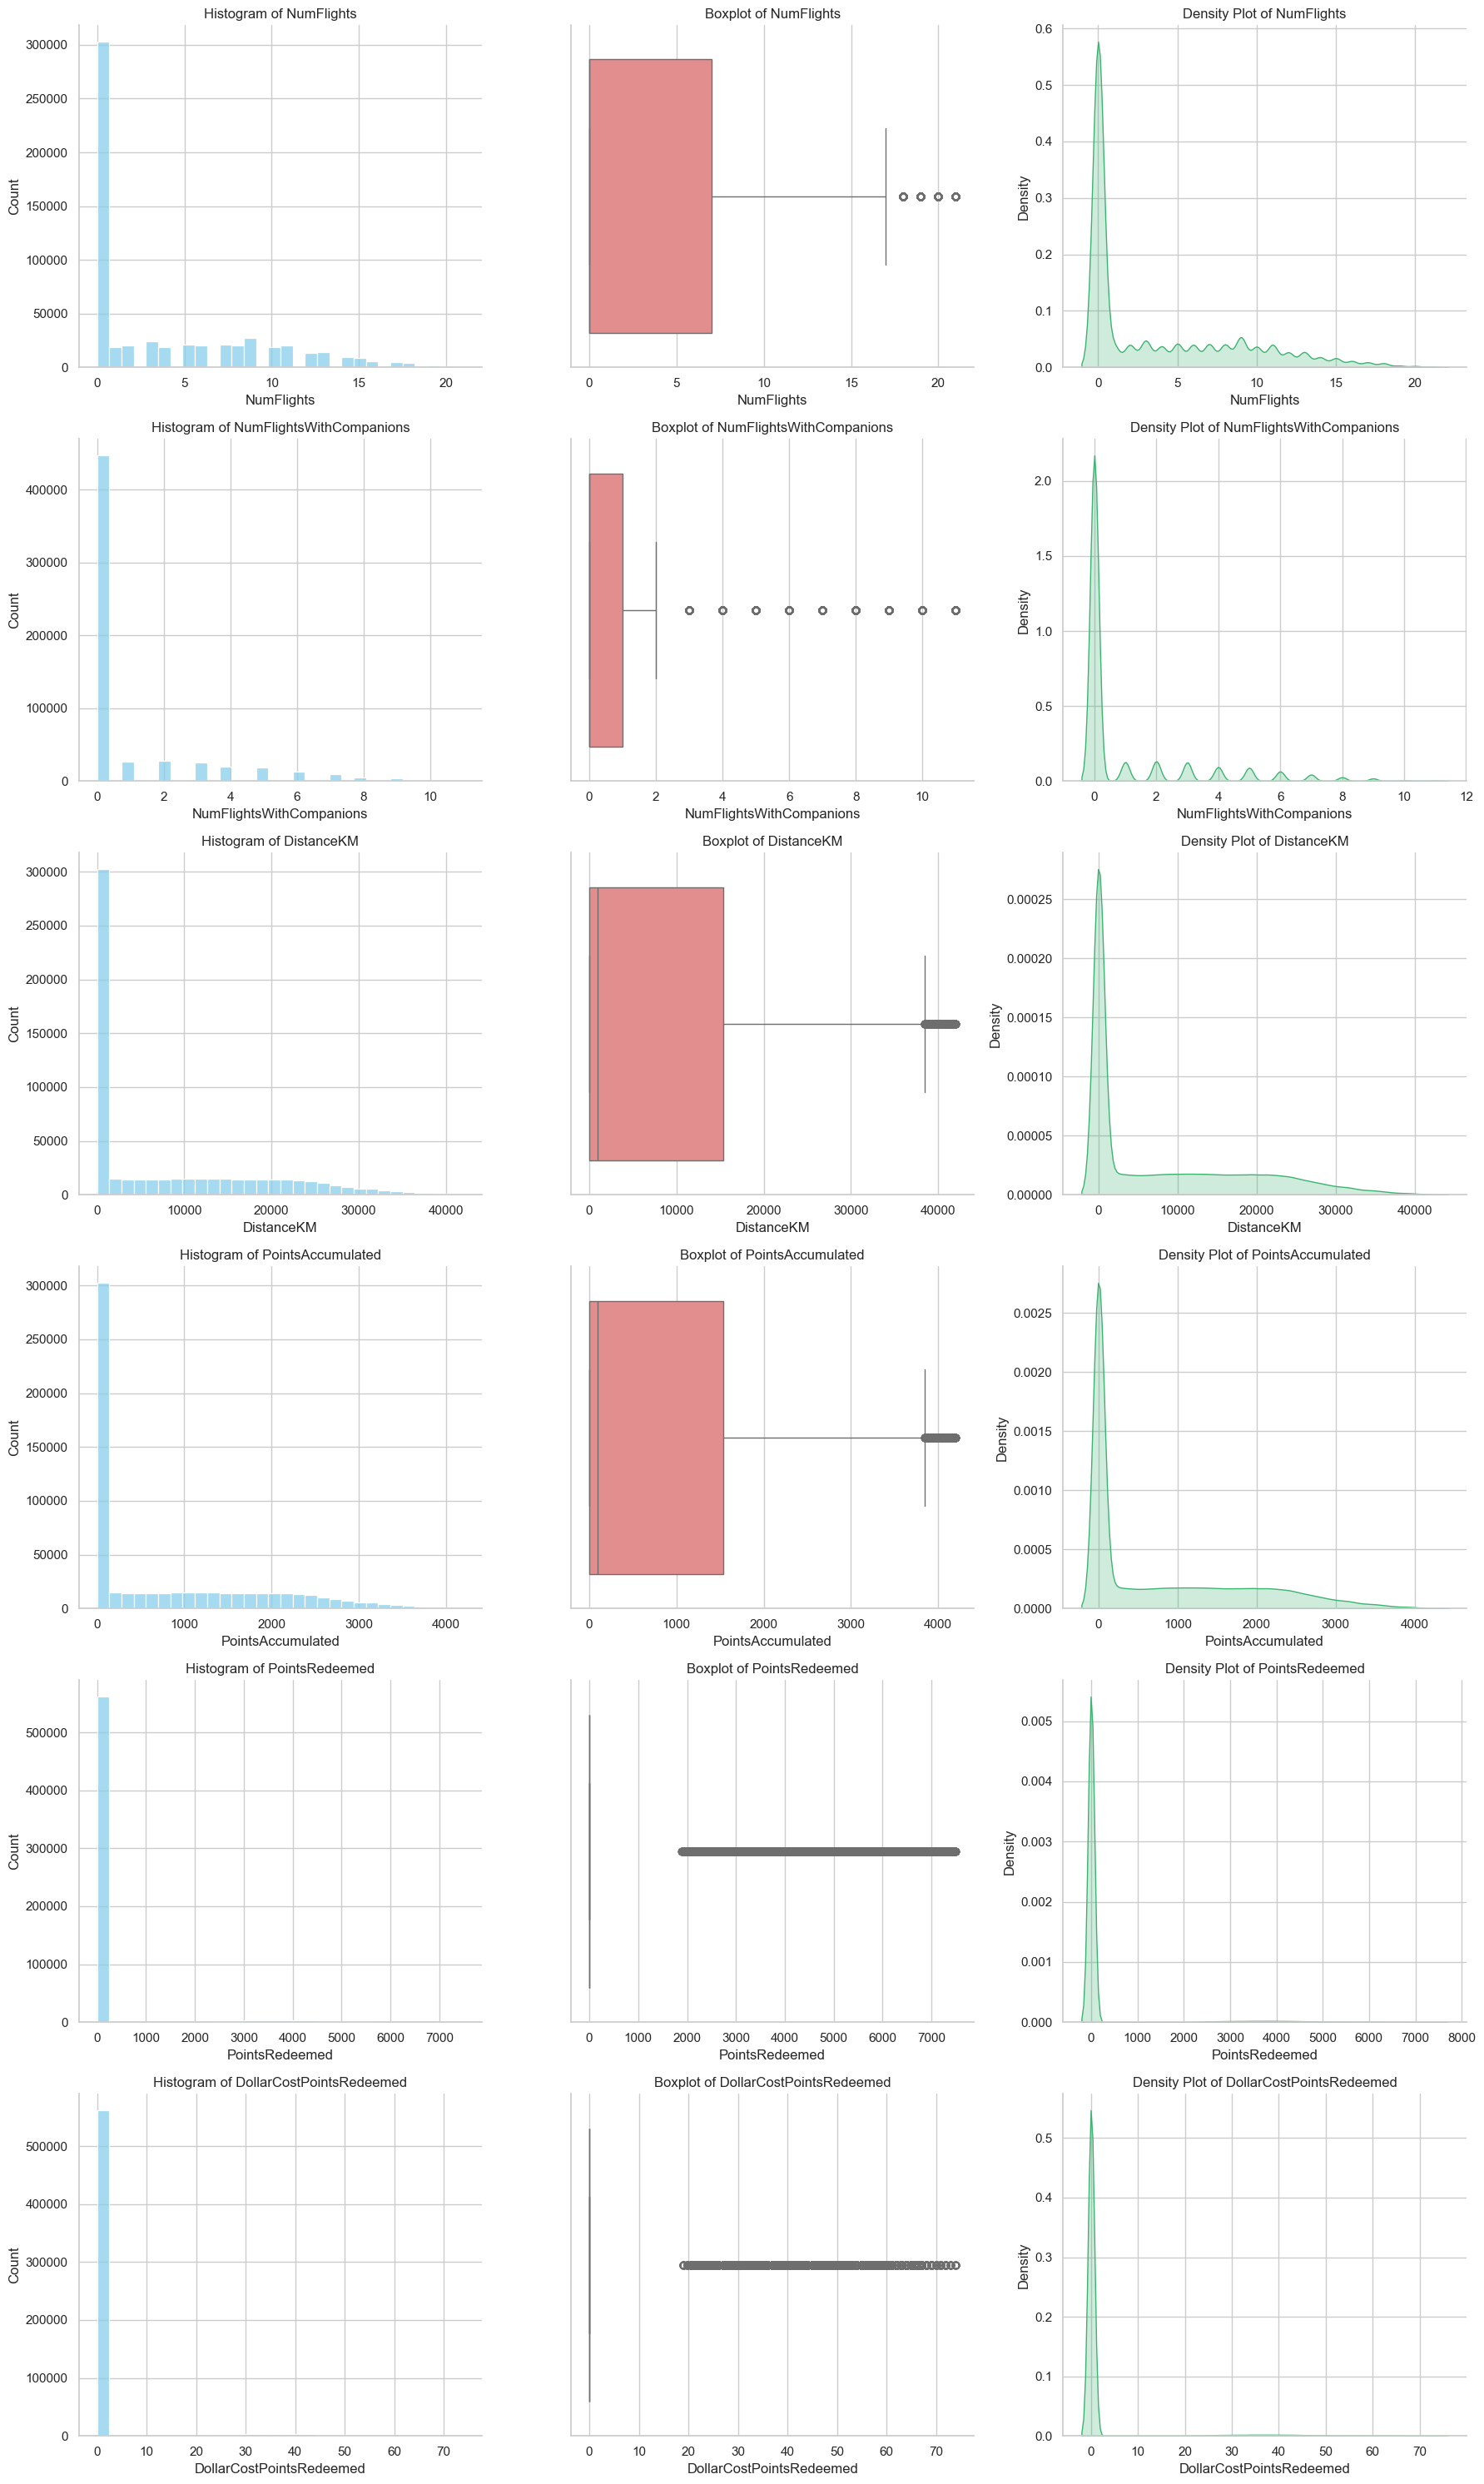

In [568]:
# Create a figure with 3 columns (hist, box, kde)
n_features = len(flights_num.columns)
n_cols = 3
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# If there’s only one feature, make axes 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(flights_num.columns):
    # Histogram
    sns.histplot(flights_num[col], bins=30, kde=False, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=flights_num[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

    # Density plot (KDE)
    sns.kdeplot(flights_num[col].dropna(), ax=axes[i, 2], fill=True, color='mediumseagreen')
    axes[i, 2].set_title(f'Density Plot of {col}')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')

plt.tight_layout()
sns.despine(fig)
plt.show()


## 6.1 Flight Metrics grouped by customer  <a class="anchor" id="Tenure Days"></a>


- We will add some flight metrics grouped by customer into the customers dataframe. First we calculate them in a new dataframe and then we merge them into the customers dataframe.

### 6.1 Flights Aggregated Metrics  <a class="anchor" id="flights-Aggregated"></a>


In [569]:
# Basic flight metrics per customer
flight_aggs = flights.groupby('Loyalty#').agg(
    # Aggregated Values
    total_flights=('NumFlights', 'sum'),
    total_flights_with_companions=('NumFlightsWithCompanions', 'sum'), 
    total_distance=('DistanceKM', 'sum'),
    total_points_accumulated=('PointsAccumulated', 'sum'),
    total_points_redeemed=('PointsRedeemed', 'sum'),
    total_cost_redeemed=('DollarCostPointsRedeemed', 'sum'),
    average_distance_per_flight=('DistanceKM', lambda x: round(x.sum() / x.count(), 2) if x.count() > 0 else 0)
).reset_index()

print("Flight aggregations summary:")

# Add derived metrics
flight_aggs['points_redemption_ratio'] = (
    flight_aggs['total_points_redeemed'] / 
    flight_aggs['total_points_accumulated'].replace(0, np.nan)
).fillna(0)

flight_aggs['companion_flight_ratio'] = (
    flight_aggs['total_flights_with_companions'] / 
    flight_aggs['total_flights']
).fillna(0)

display(flight_aggs.head())


Flight aggregations summary:


,Loyalty#,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
0,100018,225,45,530230.0,53014.30,20562.8,201.9,14728.61,0.387873,0.200000
1,100102,245,55,339114.6,33903.96,18760.6,186.2,9419.85,0.553345,0.224490
2,100140,211,51,432030.8,43192.58,4896.0,48.0,12000.86,0.113353,0.241706
3,100214,108,17,364601.7,36453.77,12908.6,127.3,10127.83,0.354109,0.157407
4,100272,181,50,429630.5,42953.25,10891.4,107.0,11934.18,0.253564,0.276243


### 6.2 Merge Flights Aggregated with customers  <a class="anchor" id="flights-Aggregated"></a>


In [570]:
# Add the aggregated data from flights to the customer data
customers_aggs = customers.merge(flight_aggs, on='Loyalty#', how='left')

# Show the first 5 rows of the updated customers dataframe
display(customers_aggs.head())

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,1050,184.0,53.0,507054.9,50699.39,13517.9,134.6,14084.86,0.266628,0.288043
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,1028,275.0,30.0,426827.4,42672.54,22457.8,221.4,11856.32,0.526282,0.109091
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,1274,116.0,37.0,238376.1,23832.41,5479.6,53.2,6621.56,0.229922,0.318966
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,2144,191.0,55.0,386029.3,38595.63,16331.5,162.2,10723.04,0.423144,0.287958
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,...,1528,167.0,59.0,369242.6,36916.56,0.0,0.0,10256.74,0.000000,0.353293


We now have some new features for our customers dataframe. The next step is the analysis of all features

# 7 Deep down Analysis EDA  <a class="anchor" id="Flights-EDA"></a>



## 7.1 Value based segmentation   <a class="anchor" id="Flights-EDA"></a>


## 7.2 Behavioral Segmentation    <a class="anchor" id="Flights-EDA"></a>


## 7.3 Demographic Segmentation    <a class="anchor" id="Flights-EDA"></a>


### 7.3.1 Customer Distribution by City and Province

In [571]:
province_counts = (
    customers['Province or State']
    .value_counts(dropna=False)
    .rename_axis('Province')
    .reset_index(name='CustomerCount')
)
print("Top Provinces by Customer Count:\n")
print(province_counts)

Top Provinces by Customer Count:

                Province  CustomerCount
0                Ontario           5360
1       British Columbia           4336
2                 Quebec           3249
3                Alberta            989
4               Manitoba            666
5          New Brunswick            634
6            Nova Scotia            529
7           Saskatchewan            404
8           Newfoundland            253
9                  Yukon            108
10  Prince Edward Island             66


In [572]:
city_counts = (
    customers['City']
    .value_counts(dropna=False)
    .rename_axis('City')
    .reset_index(name='CustomerCount')
)
print("Top Cities by Customer Count:\n")
print(city_counts)

Top Cities by Customer Count:

              City  CustomerCount
0          Toronto           3326
1        Vancouver           2551
2         Montreal           2029
3         Winnipeg            666
4         Whistler            579
5          Halifax            529
6           Ottawa            507
7         Edmonton            498
8          Trenton            483
9      Quebec City            475
10    Dawson Creek            437
11     Fredericton            421
12          Regina            404
13        Kingston            397
14       Tremblant            390
15        Victoria            382
16            Hull            355
17  West Vancouver            308
18      St. John's            253
19     Thunder Bay            251
20         Sudbury            224
21         Moncton            213
22         Calgary            192
23           Banff            186
24          London            172
25     Peace River            113
26      Whitehorse            108
27         Kelown

In [573]:
province_city_counts = (
    customers.groupby(['Province or State', 'City'])
    .size()
    .reset_index(name='CustomerCount')
    .sort_values('CustomerCount', ascending=False)
    .reset_index(drop=True)
)
print("Top Province + City combinations by Customer Count:\n")
print(province_city_counts)

Top Province + City combinations by Customer Count:

       Province or State            City  CustomerCount
0                Ontario         Toronto           3326
1       British Columbia       Vancouver           2551
2                 Quebec        Montreal           2029
3               Manitoba        Winnipeg            666
4       British Columbia        Whistler            579
5            Nova Scotia         Halifax            529
6                Ontario          Ottawa            507
7                Alberta        Edmonton            498
8                Ontario         Trenton            483
9                 Quebec     Quebec City            475
10      British Columbia    Dawson Creek            437
11         New Brunswick     Fredericton            421
12          Saskatchewan          Regina            404
13               Ontario        Kingston            397
14                Quebec       Tremblant            390
15      British Columbia        Victoria           

In [574]:
# === Tunables ===
TOP_N_PER_PROVINCE = 8      # set None to keep all cities
ADD_OTHER_BUCKET = True     # put smaller cities into "Other" per province

# --- Prep counts ---
counts = (
    customers.groupby(['Province or State','City'])
    .size()
    .reset_index(name='CustomerCount')
)

# Handle missing labels cleanly
counts['Province or State'] = counts['Province or State'].fillna('Unknown Province')
counts['City'] = counts['City'].fillna('Unknown City')

# Province totals and shares
prov_totals = counts.groupby('Province or State')['CustomerCount'].transform('sum')
total = counts['CustomerCount'].sum()
counts['ShareInProvince'] = counts['CustomerCount'] / prov_totals
counts['ShareTotal'] = counts['CustomerCount'] / total

# Keep top-N cities per province (optional), bucket others as "Other"
if TOP_N_PER_PROVINCE is not None and ADD_OTHER_BUCKET:
    counts = counts.sort_values(['Province or State','CustomerCount'], ascending=[True, False])
    counts['RankInProvince'] = counts.groupby('Province or State')['CustomerCount'].rank(method='first', ascending=False)
    top = counts[counts['RankInProvince'] <= TOP_N_PER_PROVINCE].copy()
    other = counts[counts['RankInProvince'] > TOP_N_PER_PROVINCE].copy()

    if not other.empty:
        other_sum = (
            other.groupby('Province or State', as_index=False)
                 .agg({'CustomerCount':'sum'})
                 .rename(columns={'CustomerCount':'CustomerCount'})
        )
        other_sum['City'] = 'Other'
        # recompute shares for "Other"
        prov_total_map = top.groupby('Province or State')['CustomerCount'].sum().add(
            other_sum.set_index('Province or State')['CustomerCount'], fill_value=0
        )
        other_sum['ShareInProvince'] = other_sum.apply(
            lambda r: r['CustomerCount'] / prov_total_map[r['Province or State']], axis=1
        )
        other_sum['ShareTotal'] = other_sum['CustomerCount'] / total

        counts = pd.concat([top[['Province or State','City','CustomerCount','ShareInProvince','ShareTotal']], 
                            other_sum[['Province or State','City','CustomerCount','ShareInProvince','ShareTotal']]], 
                           ignore_index=True)

# Sort for nicer legend order
counts = counts.sort_values(['CustomerCount'], ascending=False)

# Treemap
fig = px.treemap(
    counts,
    path=['Province or State', 'City'],
    values='CustomerCount',
    color='Province or State',                 # color by province for clear grouping
    title='Cities within Provinces (Treemap, sized by customer count)',
)

# Better labels + hover
fig.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Province: %{parent}<br>"
        "Customers: %{value:,}<br>"
        "Share of province: %{customdata[0]:.1%}<br>"
        "Share of total: %{customdata[1]:.1%}<extra></extra>"
    ),
    customdata=counts[['ShareInProvince','ShareTotal']],
    texttemplate="%{label}<br>%{value:,}",
    textfont_size=12,
    marker=dict(line=dict(width=1))
)

# Layout polish
fig.update_layout(
    height=700,
    margin=dict(l=20, r=20, t=60, b=20),
    uniformtext=dict(minsize=10, mode='show')
)

fig.show()


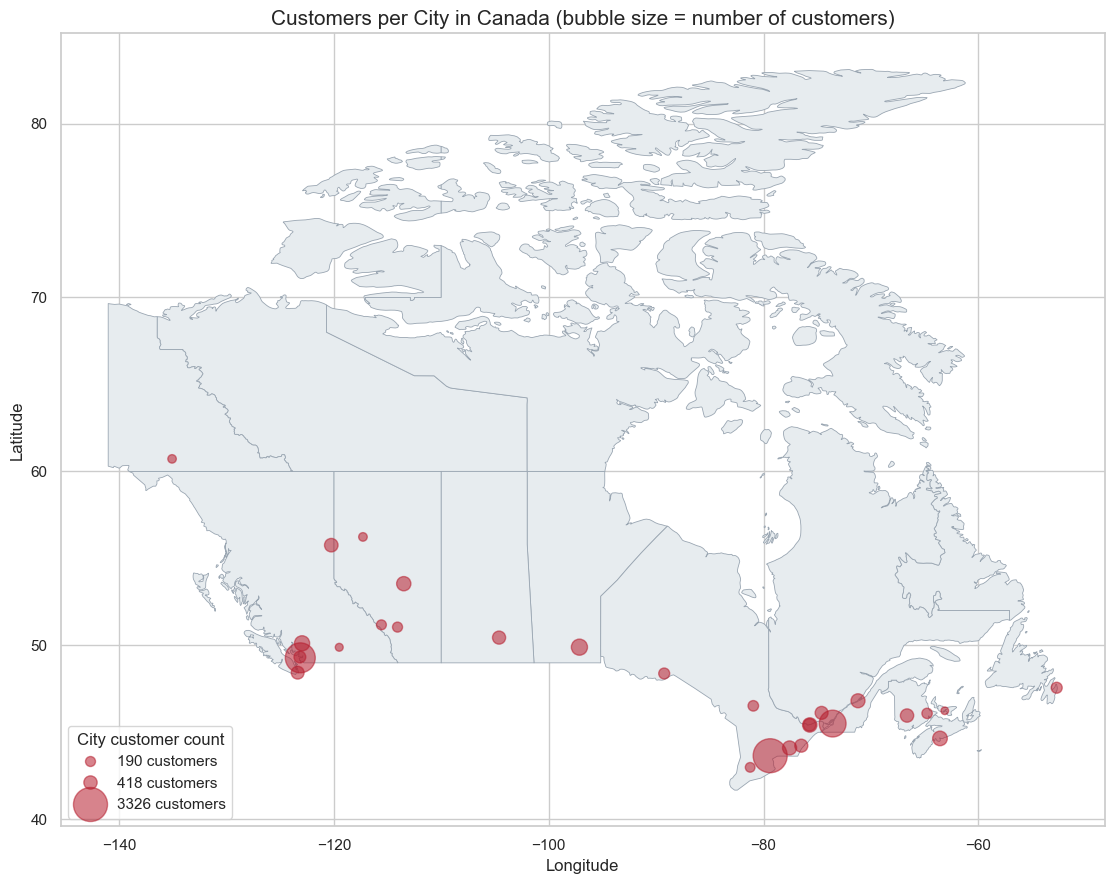

In [575]:
# 1) Prepare data
df = customers.copy()
df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# Aggregate customers per city
city_agg = (
    df.groupby(["Province or State", "City"])
      .agg(CustomerCount=("City", "size"),
           Latitude=("Latitude", "mean"),
           Longitude=("Longitude", "mean"))
      .reset_index()
)

# 2) Canada provinces layer
admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()

# 3) GeoDataFrame for city bubbles
cities_gdf = gpd.GeoDataFrame(
    city_agg,
    geometry=gpd.points_from_xy(city_agg["Longitude"], city_agg["Latitude"]),
    crs="EPSG:4326"
)

# 4) Size scaling (scatter 's' is area in points^2)
counts = cities_gdf["CustomerCount"].astype(float).values
size_min, size_max = 30, 600  # adjust if needed
if counts.size > 0:
    cmin, cmax = counts.min(), counts.max()
    if cmin == cmax:
        sizes = np.full_like(counts, (size_min + size_max) / 2.0)
    else:
        sizes = np.interp(counts, (cmin, cmax), (size_min, size_max))
else:
    sizes = np.array([])

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 9))
canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)

cities_gdf.plot(
    ax=ax,
    markersize=sizes,            # bubble sizes (area)
    color="#B61E2E",
    alpha=0.55
)

ax.set_title("Customers per City in Canada (bubble size = number of customers)", fontsize=15)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# --- Custom bubble legend (robust across Matplotlib versions) ---
if counts.size > 0:
    # Choose representative counts (min, median, max or 3 quantiles)
    reps = np.unique(np.ceil(np.quantile(counts, [0.2, 0.6, 1.0])).astype(int))
    # Map those counts to scatter areas and then to Line2D marker sizes (radius ~ sqrt(area))
    rep_sizes = []
    for r in reps:
        if cmin == cmax:
            s = (size_min + size_max) / 2.0
        else:
            s = np.interp(r, (cmin, cmax), (size_min, size_max))
        rep_sizes.append(s)

    handles = [
        Line2D([0], [0],
               marker='o', linestyle='',
               markersize=np.sqrt(s),   # convert area to marker size
               markerfacecolor="#B61E2E", markeredgecolor="#B61E2E", alpha=0.55)
        for s in rep_sizes
    ]
    labels = [f"{int(r)} customers" for r in reps]
    ax.legend(handles, labels, title="City customer count", frameon=True, loc="lower left")

plt.tight_layout(); plt.show()



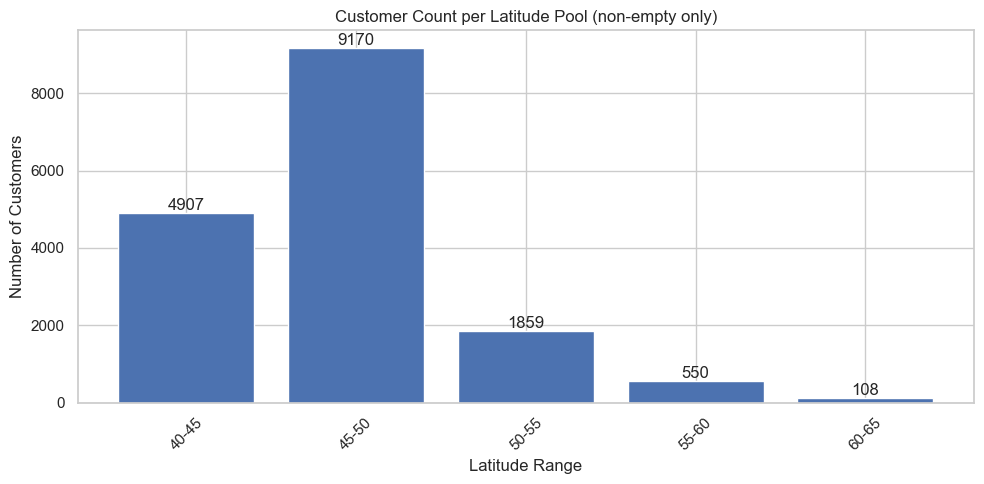

In [576]:
# --- bins e contagem ---
lat_bins = range(40, 91, 5)
lat_labels = [f"{b}-{b+5}" for b in lat_bins[:-1]]

lat_pool = pd.cut(
    customers['Latitude'],
    bins=lat_bins,
    labels=lat_labels,
    include_lowest=True
)
lat_counts = (
    lat_pool.value_counts()
    .rename_axis('LatitudePool')
    .reset_index(name='CustomerCount')
    .sort_values('LatitudePool')  # ordem natural dos bins
)

# manter só pools com > 0
lat_counts = lat_counts[lat_counts['CustomerCount'] > 0].reset_index(drop=True)

# --- gráfico ---
plt.figure(figsize=(10, 5))
plt.bar(lat_counts['LatitudePool'], lat_counts['CustomerCount'])
plt.title('Customer Count per Latitude Pool (non-empty only)')
plt.xlabel('Latitude Range')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# rótulos em cima de cada barra
for i, v in enumerate(lat_counts['CustomerCount']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

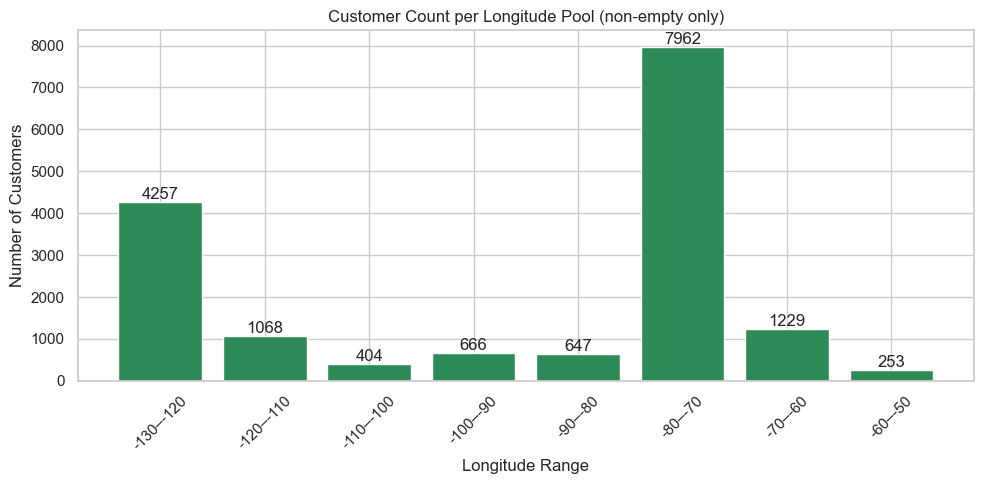

In [577]:
# --- bins e labels ---
lon_bins = range(-130, -49, 10)
lon_labels = [f"{b}–{b+10}" for b in lon_bins[:-1]]

# criar pools
lon_pool = pd.cut(
    customers['Longitude'],
    bins=lon_bins,
    labels=lon_labels,
    include_lowest=True
)

# contagem por pool
lon_counts = (
    lon_pool.value_counts()
    .rename_axis('LongitudePool')
    .reset_index(name='CustomerCount')
    .sort_values('LongitudePool')  # ordenar pelos intervalos
)

# manter só os pools com casos (>0)
lon_counts = lon_counts[lon_counts['CustomerCount'] > 0].reset_index(drop=True)

# --- gráfico ---
plt.figure(figsize=(10, 5))
plt.bar(lon_counts['LongitudePool'], lon_counts['CustomerCount'], color='seagreen')
plt.title('Customer Count per Longitude Pool (non-empty only)')
plt.xlabel('Longitude Range')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# rótulos com valores em cima das barras
for i, v in enumerate(lon_counts['CustomerCount']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [578]:
# --- Define bins and labels ---
lat_bins = range(40, 91, 5)          # 40–90 step 5
lon_bins = range(-130, -49, 10)      # -130–-50 step 10
lat_labels = [f"{b}–{b+5}" for b in lat_bins[:-1]]
lon_labels = [f"{b}–{b+10}" for b in lon_bins[:-1]]

# Pools
customers['LatPool'] = pd.cut(customers['Latitude'], bins=lat_bins, labels=lat_labels, include_lowest=True)
customers['LonPool'] = pd.cut(customers['Longitude'], bins=lon_bins, labels=lon_labels, include_lowest=True)

# Count customers per city within each pool
# If you have CustomerID and want unique customers, replace .size() with .nunique()
city_counts = (
    customers.groupby(['LatPool', 'LonPool', 'City'])
    .size()
    .reset_index(name='CustomerCount')
)

# Remove cities without pool (outside bounds)
city_counts = city_counts.dropna(subset=['LatPool','LonPool','City'])

fig = px.treemap(
    city_counts,
    path=['LatPool', 'LonPool', 'City'],     # hierarchy: Lat → Lon → City
    values='CustomerCount',
    title='Cities within Latitude/Longitude Pools (sized by customer count)'
)

# Nicer hover info
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Path: %{currentPath}<br>Customers: %{value:,}<extra></extra>"
)

fig.update_layout(margin=dict(l=20, r=20, t=60, b=20), height=750)
fig.show()

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\4046186848.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:17

### 7.2.3 Province Analysis

#### Province and Gender Distribution

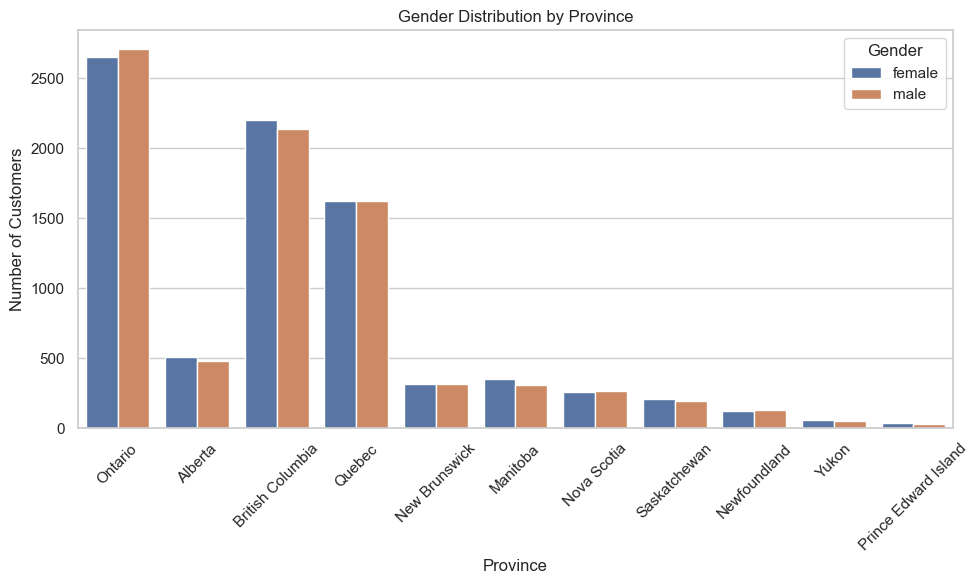

In [579]:
plt.figure(figsize=(10,6))
sns.countplot(data=customers, x='Province or State', hue='Gender')
plt.title('Gender Distribution by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Province and Ecucation Distribution

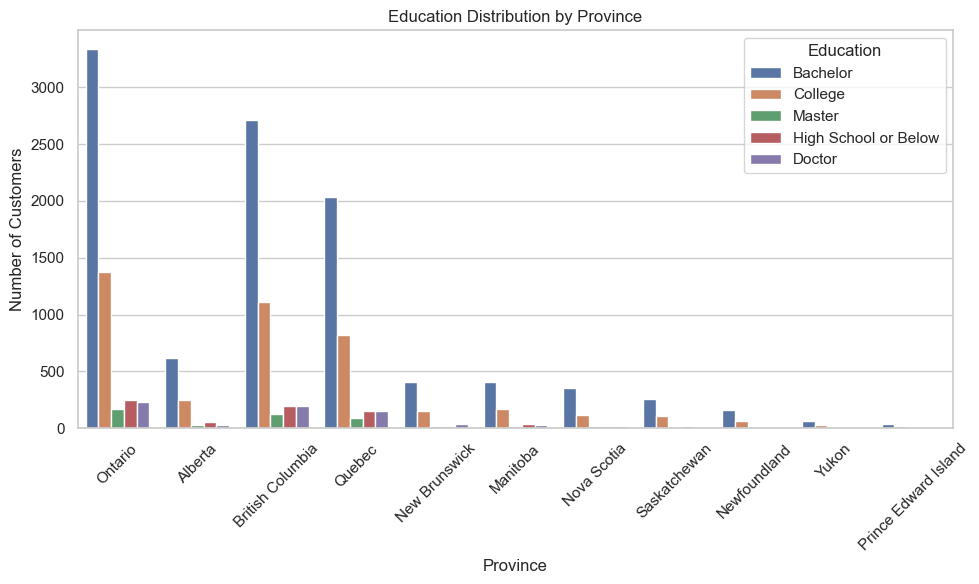

In [580]:
plt.figure(figsize=(10,6))
sns.countplot(data=customers, x='Province or State', hue='Education')
plt.title('Education Distribution by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Province and Income (sum of total income by customers) Distribution

In [581]:
income_sum = (
    customers.groupby('Province or State')['Income']
    .sum()
    .reset_index(name='TotalIncome')
    .sort_values('TotalIncome', ascending=False)
)

fig = px.bar(
    income_sum,
    x='Province or State',
    y='TotalIncome',
    title='Total Income by Province (Sum)',
    text_auto='.2s',
    color='TotalIncome',
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Income', height=500)
fig.show()

#### Province and Income (mean of all customer) Distribution

In [582]:
income_mean = (
    customers.groupby('Province or State')['Income']
    .mean()
    .reset_index(name='AverageIncome')
    .sort_values('AverageIncome', ascending=False)
)

fig = px.bar(
    income_mean,
    x='Province or State',
    y='AverageIncome',
    title='Average Income per Customer by Province',
    text_auto='.2f',
    color='AverageIncome',
    color_continuous_scale='Viridis'
)

# Add thousand separators to y-axis and hover labels
fig.update_layout(
    xaxis_title='Province',
    yaxis_title='Average Income',
    height=500,
    yaxis_tickformat=',',          # ← adds thousand separators
)

# Format hover labels and text with commas
fig.update_traces(
    hovertemplate='Province: %{x}<br>Average Income: %{y:,.0f}',
    texttemplate='%{y:,.0f}'      # ← show commas in bar text labels
)

fig.show()


#### Province and Marital Status Distribution

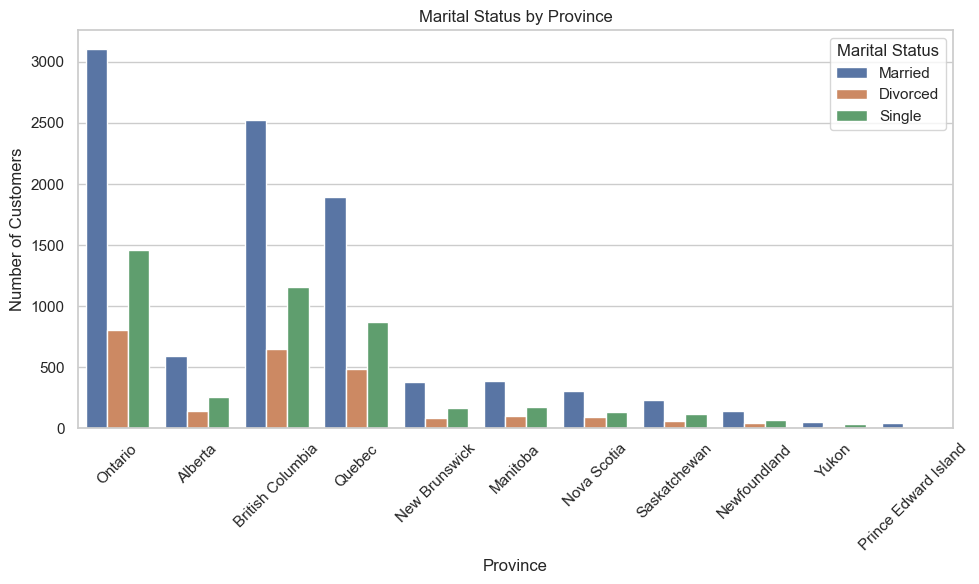

In [583]:
plt.figure(figsize=(10,6))
sns.countplot(data=customers, x='Province or State', hue='Marital Status')
plt.title('Marital Status by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Province and LoyaltyStatus Distribution

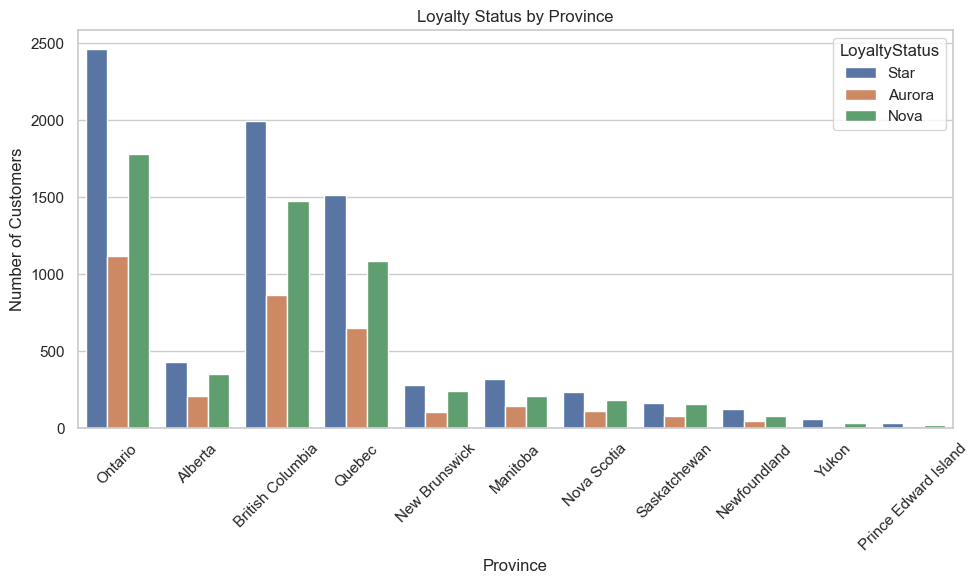

In [584]:
plt.figure(figsize=(10,6))
sns.countplot(data=customers, x='Province or State', hue='LoyaltyStatus')
plt.title('Loyalty Status by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Province and Customer LifeTime Value (sum) Distribution

In [585]:
clv_sum = (
    customers.groupby('Province or State')['Customer Lifetime Value']
    .sum()
    .reset_index(name='TotalCLV')
    .sort_values('TotalCLV', ascending=False)
)

fig = px.bar(
    clv_sum,
    x='Province or State',
    y='TotalCLV',
    title='Total Customer Lifetime Value by Province (Sum)',
    text_auto='.2s',
    color='TotalCLV',
    color_continuous_scale='Purples'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total CLV', height=500)
fig.show()

#### Province and Customer LifeTime Value (Mean) Distribution

In [586]:
clv_mean = (
    customers.groupby('Province or State')['Customer Lifetime Value']
    .mean()
    .reset_index(name='AverageCLV')
    .sort_values('AverageCLV', ascending=False)
)

fig = px.bar(
    clv_mean,
    x='Province or State',
    y='AverageCLV',
    title='Average Customer Lifetime Value per Customer by Province',
    text_auto='.2f',
    color='AverageCLV',
    color_continuous_scale='Magma'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Average CLV', height=500)
fig.show()

#### Province and IsActive Distribution

In [587]:
active_counts = (
    customers.groupby(['Province or State', 'IsActive'])
    .size()
    .reset_index(name='CustomerCount')
)

fig = px.bar(
    active_counts,
    x='Province or State',
    y='CustomerCount',
    color='IsActive',
    barmode='group',
    title='Active vs Inactive Customers by Province'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Number of Customers', height=500)
fig.show()

#### Province and Total Flights Distribution

In [588]:
flights_sum = (
    customers_aggs.groupby('Province or State')['total_flights']
    .sum()
    .reset_index(name='TotalFlights')
    .sort_values('TotalFlights', ascending=False)
)

fig = px.bar(
    flights_sum,
    x='Province or State',
    y='TotalFlights',
    title='Total Flights by Province',
    text_auto='.0f',
    color='TotalFlights',
    color_continuous_scale='Tealgrn'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Flights', height=500)
fig.show()

#### Province and Total Distance Distribution

In [589]:
distance_sum = (
    customers_aggs.groupby('Province or State')['total_distance']
    .sum()
    .reset_index(name='TotalDistance')
    .sort_values('TotalDistance', ascending=False)
)

fig = px.bar(
    distance_sum,
    x='Province or State',
    y='TotalDistance',
    title='Total Distance by Province',
    text_auto='.0f',
    color='TotalDistance',
    color_continuous_scale='Cividis'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Distance (km)', height=500)
fig.show()


### 7.3.3 City Analysis

#### City and Province distribution

In [590]:
top_cities_by_province = (
    customers.groupby(["Province or State", "City"])
             .size()
             .rename("CustomerCount")
             .reset_index()
             .sort_values(["Province or State", "CustomerCount"], ascending=[True, False])
             .groupby("Province or State")
             .head(TOP_N)
)

# (Opcional) percentagem dentro da province
totals = top_cities_by_province.groupby("Province or State")["CustomerCount"].transform("sum")
top_cities_by_province["ShareWithinTopN"] = 100 * top_cities_by_province["CustomerCount"] / totals

# Mostrar
try:
    df_show = top_cities_by_province.copy()
    df_show["CustomerCount"] = df_show["CustomerCount"].map("{:,}".format)
    df_show["ShareWithinTopN"] = df_show["ShareWithinTopN"].map("{:.1f}%".format)
    display(df_show)
except NameError:
    print(top_cities_by_province)

,Province or State,City,CustomerCount,ShareWithinTopN
2,Alberta,Edmonton,498,50.4%
1,Alberta,Calgary,192,19.4%
0,Alberta,Banff,186,18.8%
3,Alberta,Peace River,113,11.4%
6,British Columbia,Vancouver,"2,551",58.8%
9,British Columbia,Whistler,579,13.4%
4,British Columbia,Dawson Creek,437,10.1%
7,British Columbia,Victoria,382,8.8%
8,British Columbia,West Vancouver,308,7.1%
5,British Columbia,Kelowna,79,1.8%


#### City and Income (sum) Distribution

In [591]:
# --- 1) Prepare data
df = customers.copy()
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df = df.dropna(subset=["Income", "City"])

# --- 2) Total income per city
city_sum = (
    df.groupby("City", as_index=False)["Income"]
      .sum()
      .sort_values("Income", ascending=False)
      .head(10)
)

# --- 3) Plot
fig = px.bar(
    city_sum,
    x="City",
    y="Income",
    title="Top 10 Cities by Total Income",
    text_auto=".0f",
    color="Income",
    color_continuous_scale="Cividis"
)

# Format with thousand separators
fig.update_traces(texttemplate="%{y:,.0f}")
fig.update_layout(
    xaxis_title="City",
    yaxis_title="Total Income",
    yaxis_tickformat=",",
    height=500
)

fig.show()

#### City and Income (average) Distribution

In [592]:
# --- 1) Prepare data
df = customers.copy()
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df = df.dropna(subset=["Income", "City"])

# --- 2) Average income per city
city_mean = (
    df.groupby("City", as_index=False)["Income"]
      .mean()
      .sort_values("Income", ascending=False)
      .head(10)
)

# --- 3) Plot
fig = px.bar(
    city_mean,
    x="City",
    y="Income",
    title="Top 10 Cities by Average Income",
    text_auto=".0f",
    color="Income",
    color_continuous_scale="Viridis"
)

# Format with thousand separators
fig.update_traces(texttemplate="%{y:,.0f}")
fig.update_layout(
    xaxis_title="City",
    yaxis_title="Average Income",
    yaxis_tickformat=",",
    height=500
)

fig.show()


#### City and Gender Disttibution

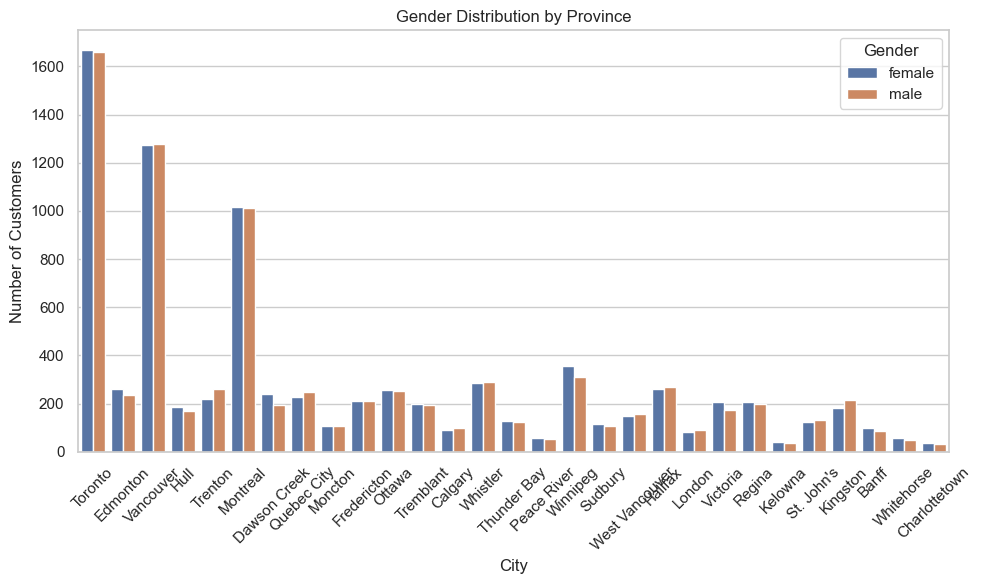

In [593]:
plt.figure(figsize=(10,6))
sns.countplot(data=customers, x='City', hue='Gender')
plt.title('Gender Distribution by Province')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### City and Customer LifeTime Value distribution

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\2460499819.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




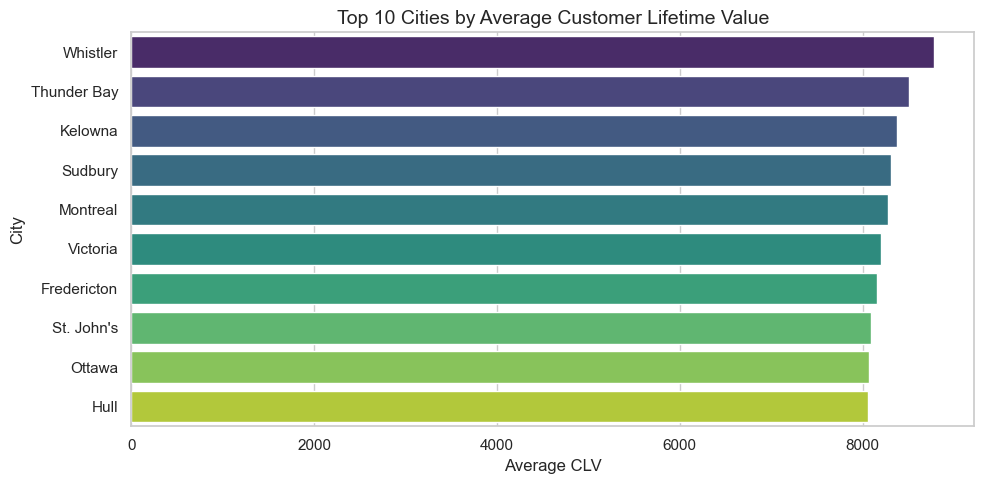

In [594]:
df = customers.copy()
df["Customer Lifetime Value"] = pd.to_numeric(df["Customer Lifetime Value"], errors="coerce")
df = df.dropna(subset=["City", "Customer Lifetime Value"])

# Average per city
clv_city = (
    df.groupby("City", as_index=False)["Customer Lifetime Value"]
      .mean()
      .sort_values("Customer Lifetime Value", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=clv_city,
    x="Customer Lifetime Value",
    y="City",
    palette="viridis"
)
plt.title("Top 10 Cities by Average Customer Lifetime Value", fontsize=14)
plt.xlabel("Average CLV")
plt.ylabel("City")
plt.tight_layout()
plt.show()

#### City and Customer Tenure Days distribution

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\130689129.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




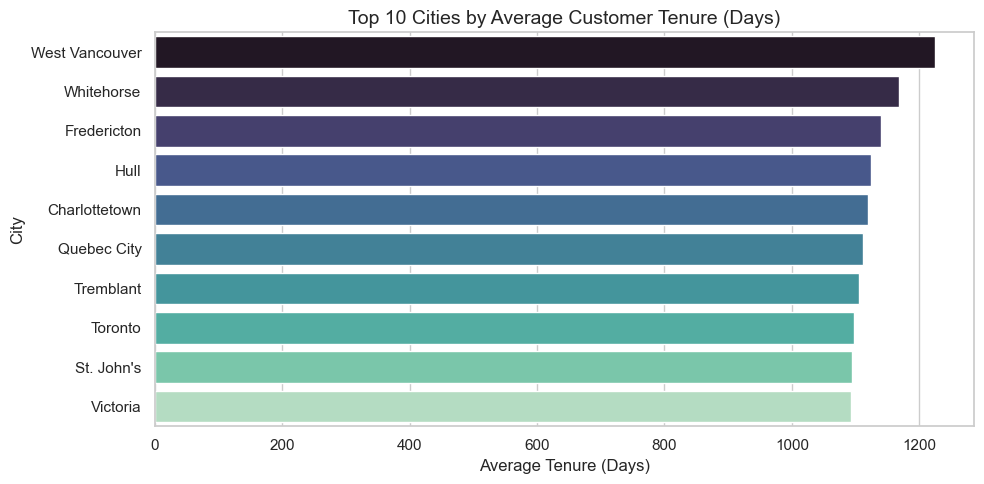

In [595]:
df = customers.copy()
df["CustomerTenureDays"] = pd.to_numeric(df["CustomerTenureDays"], errors="coerce")
df = df.dropna(subset=["City", "CustomerTenureDays"])

tenure_city = (
    df.groupby("City", as_index=False)["CustomerTenureDays"]
      .mean()
      .sort_values("CustomerTenureDays", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tenure_city,
    x="CustomerTenureDays",
    y="City",
    palette="mako"
)
plt.title("Top 10 Cities by Average Customer Tenure (Days)", fontsize=14)
plt.xlabel("Average Tenure (Days)")
plt.ylabel("City")
plt.tight_layout()
plt.show()


#### City and TotalFlights distribution

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3225931751.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




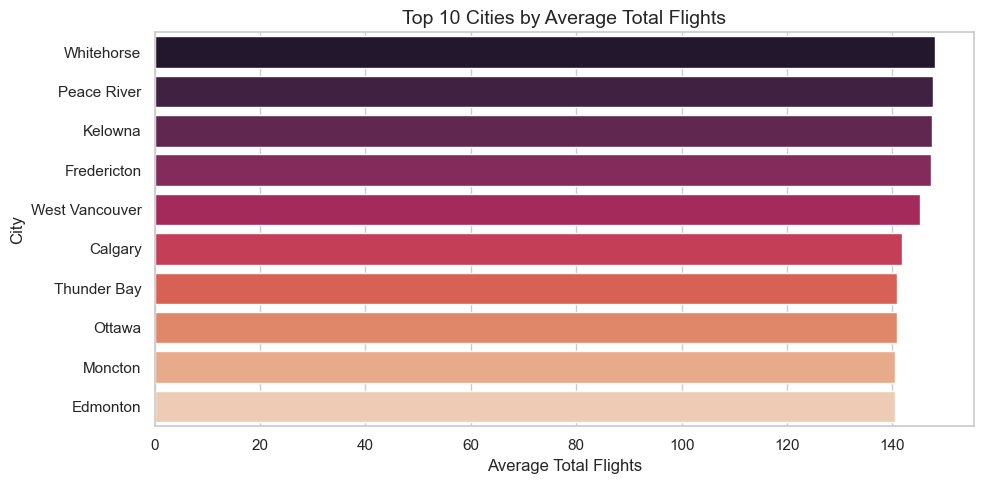

In [600]:
df = customers_aggs.copy()
df["total_flights"] = pd.to_numeric(df["total_flights"], errors="coerce")
df = df.dropna(subset=["City", "total_flights"])

flights_city = (
    df.groupby("City", as_index=False)["total_flights"]
      .mean()
      .sort_values("total_flights", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=flights_city,
    x="total_flights",
    y="City",
    palette="rocket"
)
plt.title("Top 10 Cities by Average Total Flights", fontsize=14)
plt.xlabel("Average Total Flights")
plt.ylabel("City")
plt.tight_layout()
plt.show()


#### City vs TOtal Distance

C:\Users\Duarte\AppData\Local\Temp\ipykernel_2456\3697646342.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




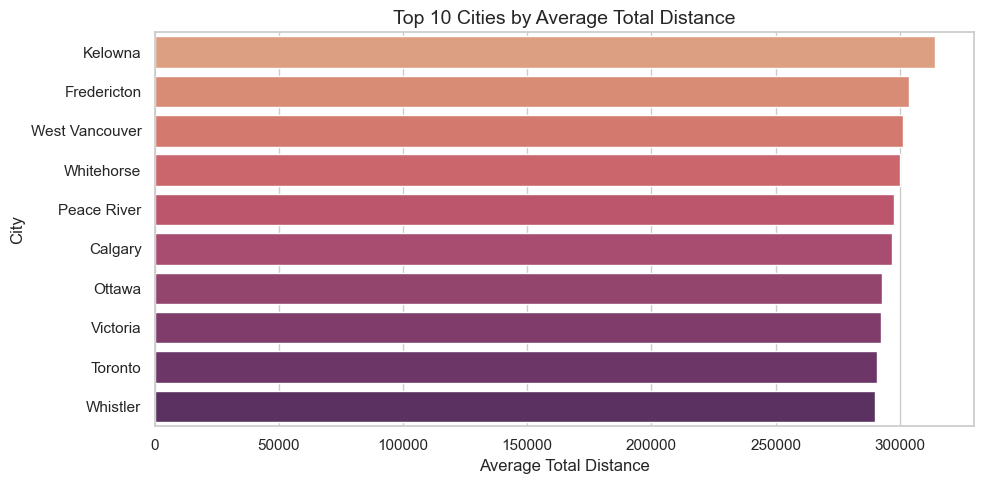

In [603]:
df = customers_aggs.copy()
df["total_distance"] = pd.to_numeric(df["total_distance"], errors="coerce")
df = df.dropna(subset=["City", "total_distance"])

distance_city = (
    df.groupby("City", as_index=False)["total_distance"]
      .mean()
      .sort_values("total_distance", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=distance_city,
    x="total_distance",
    y="City",
    palette="flare"
)
plt.title("Top 10 Cities by Average Total Distance", fontsize=14)
plt.xlabel("Average Total Distance")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# 6 Conclusion <a class="anchor" id="Flights-EDA"></a>


# Old Codes

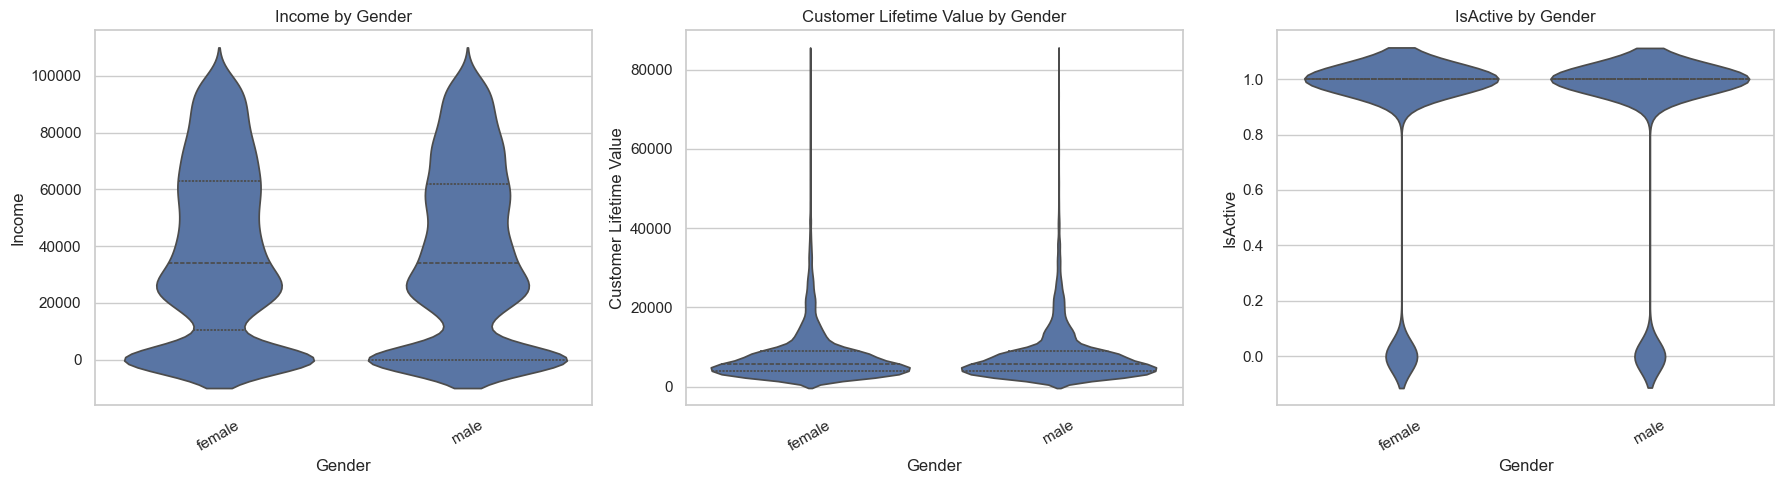

In [ ]:
# Numeric vs Categorical — box/violin by Gender

cat_for_group = "Gender" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")
